In [1]:
# 1. Import Pandas
import pandas as pd

In [2]:
# 2. Connect Google Drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATA_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/data/"

In [4]:
# 4. Load dataset
df = pd.read_csv(DATA_PATH + "results.csv")

In [5]:
# 5. Verify
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [6]:
# 6. Check shape
df.shape

(49547, 9)

In [7]:
df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')

In [8]:
df.dtypes

,0
date,object
home_team,object
away_team,object
home_score,int64
away_score,int64
tournament,object
city,object
country,object
neutral,bool


In [9]:
df.isna().sum()

,0
date,0
home_team,0
away_team,0
home_score,0
away_score,0
tournament,0
city,0
country,0
neutral,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["date"] = pd.to_datetime(df["date"])

In [12]:
df.dtypes

,0
date,datetime64[ns]
home_team,object
away_team,object
home_score,int64
away_score,int64
tournament,object
city,object
country,object
neutral,bool


In [13]:
df["date"].min()

Timestamp('1872-11-30 00:00:00')

In [14]:
df["date"].max()

Timestamp('2026-08-26 00:00:00')

In [15]:
df["tournament"].value_counts()

,count
tournament,
Friendly,18385
FIFA World Cup qualification,8771
UEFA Euro qualification,2824
African Cup of Nations qualification,2327
FIFA World Cup,1068
...,...
Copa Confraternidad,1
ConIFA Challenger Cup,1
Benedikt Fontana Cup,1


In [16]:
df["home_team"].nunique()

328

In [17]:
df["away_team"].nunique()

322

In [18]:
pd.concat([df["home_team"], df["away_team"]]).nunique()

337

In [19]:
teams = pd.concat([df["home_team"], df["away_team"]]).unique()

In [20]:
sorted(teams)

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'Ambazonia',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Asturias',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Canton Ticino',
 'Cape Verde',
 'Cascadia',
 'Catalonia',
 'Cayman Islands',
 'Central African Republic',
 'Central Spain',
 'Chad',
 'Chagos Islands',
 'Chameria',
 'Chechnya',
 'Chile',
 'China',
 'Cilento',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Corsica',
 'Costa Rica',
 'County of Nice'

In [21]:
df["home_team"].ne(df["home_team"].str.strip()).sum()

np.int64(0)

In [22]:
df["away_team"].ne(df["away_team"].str.strip()).sum()


np.int64(0)

In [23]:
(df["home_score"] == df["away_score"]).sum()

np.int64(11261)

In [24]:
shootouts = pd.read_csv(DATA_PATH + "shootouts.csv")

In [25]:
shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


In [26]:
shootouts["date"] = pd.to_datetime(shootouts["date"])

shootout_matches = df.merge(
    shootouts,
    on=["date", "home_team", "away_team"],
    how="inner"
)

shootout_matches.shape

(682, 11)

In [27]:
unmatched = shootouts.merge(
    df[["date", "home_team", "away_team"]],
    on=["date", "home_team", "away_team"],
    how="left",
    indicator=True
)

unmatched[unmatched["_merge"] == "left_only"]

,date,home_team,away_team,winner,first_shooter,_merge
422,2011-06-29,Saare County,Åland Islands,Åland Islands,NaN,left_only


In [28]:
df[["home_score", "away_score"]].describe()

,home_score,away_score
count,49547.000000,49547.000000
mean,1.757140,1.182715
std,1.773702,1.402353
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [29]:
(df["home_team"] == df["away_team"]).sum()

np.int64(0)

| Check | Result | Status |
|---|---:|---|
| Dataset rows | **49,547** | ✅ |
| Columns | **9** | ✅ |
| Missing values | **0** | ✅ |
| Duplicate rows | **0** | ✅ |
| Date range | **1872–2026** | ✅ |
| Tournament categories | **202** | ✅ |
| Unique teams | **337** | ✅ |
| Team whitespace issues | **0** | ✅ |
| Negative scores | **0** | ✅ |
| Same-team matches | **0** | ✅ |
| Shootout records | **683** | ✅ |
| Shootouts matched to results | **682/683** | ✅ |

In [30]:
df = df.sort_values("date").reset_index(drop=True)

df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [31]:
df.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49542,2026-08-16,Malaysia,Vietnam,0,2,ASEAN Championship,Kuala Lumpur,Malaysia,False
49543,2026-08-18,Thailand,Singapore,1,2,ASEAN Championship,Bangkok,Thailand,False
49544,2026-08-19,Vietnam,Malaysia,2,0,ASEAN Championship,Hanoi,Vietnam,False
49545,2026-08-22,Thailand,Vietnam,0,2,ASEAN Championship,Bangkok,Thailand,False
49546,2026-08-26,Vietnam,Thailand,2,2,ASEAN Championship,Hanoi,Vietnam,False


In [32]:
import numpy as np

df["result"] = np.select(
    [
        df["home_score"] > df["away_score"],
        df["home_score"] < df["away_score"]
    ],
    [
        "HOME_WIN",
        "AWAY_WIN"
    ],
    default="DRAW"
)

In [33]:
df["result"].value_counts()

,count
result,
HOME_WIN,24276
AWAY_WIN,14010
DRAW,11261


In [34]:
df["tournament"].value_counts().head(30)

,count
tournament,
Friendly,18385
FIFA World Cup qualification,8771
UEFA Euro qualification,2824
African Cup of Nations qualification,2327
FIFA World Cup,1068
Copa América,869
African Cup of Nations,845
AFC Asian Cup qualification,829
UEFA Nations League,658


In [35]:
df["decade"] = (df["date"].dt.year // 10) * 10

In [36]:
df["decade"].value_counts().sort_index()

,count
decade,
1870,13
1880,55
1890,59
1900,138
1910,330
1920,831
1930,1079
1940,833
1950,1651


In [37]:
shootout_matches["score_tied"] = (
    shootout_matches["home_score"] == shootout_matches["away_score"]
)

shootout_matches["score_tied"].value_counts()

,count
score_tied,
True,645
False,37


In [38]:
shootout_matches.loc[
    ~shootout_matches["score_tied"],
    [
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "winner"
    ]
]

,date,home_team,away_team,home_score,away_score,winner
5,1973-04-21,Senegal,Ghana,1,0,Ghana
20,1974-11-22,Libya,Tunisia,1,0,Tunisia
22,1975-07-13,Morocco,Ghana,2,0,Morocco
25,1975-12-23,Libya,Syria,1,0,Syria
30,1977-06-26,Zambia,Algeria,2,0,Zambia
32,1977-08-31,Paraguay,Argentina,2,0,Paraguay
35,1979-04-29,Cameroon,Guinea,3,0,Guinea
42,1980-07-12,Nigeria,Tunisia,2,0,Nigeria
43,1980-11-30,Zambia,Morocco,2,0,Morocco
46,1981-05-10,Rwanda,Ethiopia,1,0,Ethiopia


683 shootout records
682 matched
645 tied scores
37 non-tied/anomalous records
1 unmatched


In [39]:
df = df.drop(columns=["decade"])

df.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'result'],
      dtype='object')

In [40]:
df[
    df["tournament"] == "FIFA World Cup"
].groupby(
    df["date"].dt.year // 10 * 10
).size()

,0
date,
1930,53
1950,83
1960,64
1970,108
1980,104
1990,168
2000,128
2010,192
2020,168


In [41]:
model_df = df[df["date"].dt.year >= 2000].copy()

model_df.shape

(25485, 10)

In [42]:
print("Shape:", model_df.shape)
print("Start date:", model_df["date"].min())
print("End date:", model_df["date"].max())
print("\nTarget distribution:")
print(model_df["result"].value_counts())

Shape: (25485, 10)
Start date: 2000-01-04 00:00:00
End date: 2026-08-26 00:00:00

Target distribution:
result
HOME_WIN    12266
AWAY_WIN     7288
DRAW         5931
Name: count, dtype: int64


                HISTORICAL MATCH
                       ↓
             Pre-match team ratings
                       ↓
              Home/Neutral adjustment
                       ↓
                Expected result
                       ↓
                 Match happens
                       ↓
              Actual match result
                       ↓
                Margin of Victory
                       ↓
                 Elo rating update
                       ↓
                Next historical match

                

In [43]:
import pandas as pd
import numpy as np

test_matches = pd.DataFrame({
    "date": pd.to_datetime([
        "2020-01-01",
        "2020-01-05",
        "2020-01-10"
    ]),
    "home_team": ["Brazil", "Argentina", "Brazil"],
    "away_team": ["Argentina", "Brazil", "France"],
    "home_score": [2, 1, 0],
    "away_score": [0, 2, 1],
    "neutral": [False, True, False]
})

test_matches

,date,home_team,away_team,home_score,away_score,neutral
0,2020-01-01,Brazil,Argentina,2,0,False
1,2020-01-05,Argentina,Brazil,1,2,True
2,2020-01-10,Brazil,France,0,1,False


In [44]:
def calculate_elo(df, initial_rating=1500, K=20, home_advantage=60):

    ratings = {}
    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        # Give new teams the initial rating
        ratings.setdefault(home, initial_rating)
        ratings.setdefault(away, initial_rating)

        home_elo = ratings[home]
        away_elo = ratings[away]

        # Home advantage only for non-neutral matches
        if row["neutral"]:
            effective_home_elo = home_elo
        else:
            effective_home_elo = home_elo + home_advantage

        # Expected result
        expected_home = 1 / (
            1 + 10 ** ((away_elo - effective_home_elo) / 400)
        )

        expected_away = 1 - expected_home

        # Actual result
        if row["home_score"] > row["away_score"]:
            actual_home = 1
            actual_away = 0

        elif row["home_score"] < row["away_score"]:
            actual_home = 0
            actual_away = 1

        else:
            actual_home = 0.5
            actual_away = 0.5

        # Margin of Victory
        mov = abs(row["home_score"] - row["away_score"])

        if mov > 0:
            mov_factor = np.log(mov + 1)
        else:
            mov_factor = 1

        # Elo updates
        home_change = K * mov_factor * (actual_home - expected_home)
        away_change = K * mov_factor * (actual_away - expected_away)

        ratings[home] += home_change
        ratings[away] += away_change

        # Store pre-match information
        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,
            "home_elo": home_elo,
            "away_elo": away_elo,
            "expected_home": expected_home,
            "expected_away": expected_away,
            "actual_home": actual_home,
            "actual_away": actual_away,
            "mov": mov
        })

    return pd.DataFrame(records), ratings

In [45]:
elo_history, final_ratings = calculate_elo(test_matches)

elo_history

,date,home_team,away_team,home_elo,away_elo,expected_home,expected_away,actual_home,actual_away,mov
0,2020-01-01,Brazil,Argentina,1500.000000,1500.000000,0.585499,0.414501,1,0,2
1,2020-01-05,Argentina,Brazil,1490.892475,1509.107525,0.473810,0.526190,0,1,1
2,2020-01-10,Brazil,France,1515.675932,1500.000000,0.607216,0.392784,0,1,1


In [46]:
elo_all, final_ratings = calculate_elo(df)

In [47]:
elo_all.shape

(49547, 10)

In [48]:
elo_all.head()

,date,home_team,away_team,home_elo,away_elo,expected_home,expected_away,actual_home,actual_away,mov
0,1872-11-30,Scotland,England,1500.000000,1500.000000,0.585499,0.414501,0.5,0.5,0
1,1873-03-08,England,Scotland,1501.709974,1498.290026,0.590268,0.409732,1.0,0.0,2
2,1874-03-07,Scotland,England,1489.287300,1510.712700,0.555286,0.444714,1.0,0.0,1
3,1875-03-06,England,Scotland,1504.547659,1495.452341,0.598146,0.401854,0.5,0.5,0
4,1876-03-04,Scotland,England,1497.415254,1502.584746,0.578259,0.421741,1.0,0.0,3


In [49]:
elo_all.tail()

,date,home_team,away_team,home_elo,away_elo,expected_home,expected_away,actual_home,actual_away,mov
49542,2026-08-16,Malaysia,Vietnam,1493.431270,1528.689997,0.535545,0.464455,0.0,1.0,2
49543,2026-08-18,Thailand,Singapore,1577.867894,1351.786203,0.838461,0.161539,0.0,1.0,1
49544,2026-08-19,Vietnam,Malaysia,1540.457135,1481.664133,0.664592,0.335408,1.0,0.0,2
49545,2026-08-22,Thailand,Vietnam,1566.244362,1547.826792,0.610974,0.389026,0.0,1.0,2
49546,2026-08-26,Vietnam,Thailand,1561.251261,1552.819893,0.597227,0.402773,0.5,0.5,0


In [50]:
elo_features = elo_all[
    [
        "date",
        "home_team",
        "away_team",
        "home_elo",
        "away_elo",
        "expected_home",
        "expected_away"
    ]
].copy()

In [51]:
model_df = model_df.merge(
    elo_features,
    on=["date", "home_team", "away_team"],
    how="left"
)

In [52]:
model_df["elo_difference"] = (
    model_df["home_elo"] - model_df["away_elo"]
)

In [53]:
model_df.shape

(25485, 15)

In [54]:
model_df[
    [
        "date",
        "home_team",
        "away_team",
        "home_elo",
        "away_elo",
        "elo_difference",
        "expected_home",
        "result"
    ]
].head()

,date,home_team,away_team,home_elo,away_elo,elo_difference,expected_home,result
0,2000-01-04,Egypt,Togo,1655.606977,1454.872541,200.734435,0.817710,HOME_WIN
1,2000-01-07,Tunisia,Togo,1667.871328,1452.345463,215.525864,0.830060,HOME_WIN
2,2000-01-08,Trinidad and Tobago,Canada,1616.202718,1543.387346,72.815372,0.682340,DRAW
3,2000-01-09,Mexico,Iran,1759.343079,1716.440941,42.902138,0.561429,HOME_WIN
4,2000-01-09,Ivory Coast,Egypt,1629.213296,1658.134054,-28.920758,0.544608,HOME_WIN


In [55]:
model_df[
    [
        "home_elo",
        "away_elo",
        "expected_home",
        "expected_away",
        "elo_difference"
    ]
].isna().sum()

,0
home_elo,0
away_elo,0
expected_home,0
expected_away,0
elo_difference,0


In [56]:
from collections import defaultdict, deque

def calculate_recent_form(df, window=5):

    form_history = defaultdict(lambda: deque(maxlen=window))
    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        # Current pre-match form
        home_form = (
            sum(form_history[home]) / len(form_history[home])
            if form_history[home] else 0.5
        )

        away_form = (
            sum(form_history[away]) / len(form_history[away])
            if form_history[away] else 0.5
        )

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,
            "home_form": home_form,
            "away_form": away_form
        })

        # Result AFTER prediction
        if row["home_score"] > row["away_score"]:
            home_result = 1
            away_result = 0

        elif row["home_score"] < row["away_score"]:
            home_result = 0
            away_result = 1

        else:
            home_result = 0.5
            away_result = 0.5

        # Update history
        form_history[home].append(home_result)
        form_history[away].append(away_result)

    return pd.DataFrame(records)

In [57]:
form_all = calculate_recent_form(df)

In [58]:
form_all.head(10)

,date,home_team,away_team,home_form,away_form
0,1872-11-30,Scotland,England,0.50,0.50
1,1873-03-08,England,Scotland,0.50,0.50
2,1874-03-07,Scotland,England,0.25,0.75
3,1875-03-06,England,Scotland,0.50,0.50
4,1876-03-04,Scotland,England,0.50,0.50
5,1876-03-25,Scotland,Wales,0.60,0.50
6,1877-03-03,England,Scotland,0.40,0.70
7,1877-03-05,Wales,Scotland,0.00,0.90
8,1878-03-02,Scotland,England,0.90,0.30
9,1878-03-23,Scotland,Wales,1.00,0.00


In [59]:
model_df = model_df.merge(
    form_all,
    on=["date", "home_team", "away_team"],
    how="left"
)

In [60]:
model_df["form_difference"] = (
    model_df["home_form"] - model_df["away_form"]
)

In [61]:
model_df[
    [
        "date",
        "home_team",
        "away_team",
        "home_form",
        "away_form",
        "form_difference",
        "result"
    ]
].head(10)

,date,home_team,away_team,home_form,away_form,form_difference,result
0,2000-01-04,Egypt,Togo,0.4,0.1,0.3,HOME_WIN
1,2000-01-07,Tunisia,Togo,0.7,0.1,0.6,HOME_WIN
2,2000-01-08,Trinidad and Tobago,Canada,0.7,0.7,0.0,DRAW
3,2000-01-09,Mexico,Iran,0.6,0.6,0.0,HOME_WIN
4,2000-01-09,Ivory Coast,Egypt,0.4,0.5,-0.1,HOME_WIN
5,2000-01-09,Burkina Faso,Gabon,0.3,0.5,-0.2,DRAW
6,2000-01-09,Guatemala,Armenia,0.4,0.3,0.1,DRAW
7,2000-01-11,Bermuda,Canada,0.8,0.8,0.0,AWAY_WIN
8,2000-01-11,Burkina Faso,Cameroon,0.2,0.8,-0.6,DRAW
9,2000-01-13,Senegal,Cameroon,0.9,0.8,0.1,DRAW


In [62]:
model_df[
    ["home_form", "away_form", "form_difference"]
].isna().sum()

,0
home_form,0
away_form,0
form_difference,0


In [63]:
from collections import defaultdict, deque

def calculate_h2h(df, window=5):

    h2h_history = defaultdict(lambda: deque(maxlen=window))
    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        # Same pair regardless of home/away order
        pair = tuple(sorted([home, away]))

        history = h2h_history[pair]

        # Current home team's H2H form
        if history:
            home_h2h = sum(
                result if team == home else 1 - result
                for team, result in history
            ) / len(history)
        else:
            home_h2h = 0.5

        away_h2h = 1 - home_h2h

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,
            "home_h2h": home_h2h,
            "away_h2h": away_h2h
        })

        # Actual result from current home team's perspective
        if row["home_score"] > row["away_score"]:
            result = 1

        elif row["home_score"] < row["away_score"]:
            result = 0

        else:
            result = 0.5

        # Store result from the team appearing first
        first_team = pair[0]

        if home == first_team:
            pair_result = result
        else:
            pair_result = 1 - result

        history.append((first_team, pair_result))

    return pd.DataFrame(records)

In [64]:
h2h_all = calculate_h2h(df)

In [65]:
h2h_all.head(10)

,date,home_team,away_team,home_h2h,away_h2h
0,1872-11-30,Scotland,England,0.50,0.50
1,1873-03-08,England,Scotland,0.50,0.50
2,1874-03-07,Scotland,England,0.25,0.75
3,1875-03-06,England,Scotland,0.50,0.50
4,1876-03-04,Scotland,England,0.50,0.50
5,1876-03-25,Scotland,Wales,0.50,0.50
6,1877-03-03,England,Scotland,0.40,0.60
7,1877-03-05,Wales,Scotland,0.00,1.00
8,1878-03-02,Scotland,England,0.70,0.30
9,1878-03-23,Scotland,Wales,1.00,0.00


In [66]:
model_df = model_df.merge(
    h2h_all,
    on=["date", "home_team", "away_team"],
    how="left"
)

In [67]:
model_df["h2h_difference"] = (
    model_df["home_h2h"] - model_df["away_h2h"]
)

In [68]:
model_df[
    [
        "date",
        "home_team",
        "away_team",
        "home_h2h",
        "away_h2h",
        "h2h_difference",
        "result"
    ]
].head(10)

,date,home_team,away_team,home_h2h,away_h2h,h2h_difference,result
0,2000-01-04,Egypt,Togo,0.875000,0.125000,0.750000,HOME_WIN
1,2000-01-07,Tunisia,Togo,0.833333,0.166667,0.666667,HOME_WIN
2,2000-01-08,Trinidad and Tobago,Canada,0.100000,0.900000,-0.800000,DRAW
3,2000-01-09,Mexico,Iran,0.500000,0.500000,0.000000,HOME_WIN
4,2000-01-09,Ivory Coast,Egypt,0.700000,0.300000,0.400000,HOME_WIN
5,2000-01-09,Burkina Faso,Gabon,0.400000,0.600000,-0.200000,DRAW
6,2000-01-09,Guatemala,Armenia,0.500000,0.500000,0.000000,DRAW
7,2000-01-11,Bermuda,Canada,0.400000,0.600000,-0.200000,AWAY_WIN
8,2000-01-11,Burkina Faso,Cameroon,0.000000,1.000000,-1.000000,DRAW
9,2000-01-13,Senegal,Cameroon,0.600000,0.400000,0.200000,DRAW


In [69]:
model_df[
    ["home_h2h", "away_h2h", "h2h_difference"]
].isna().sum()

,0
home_h2h,0
away_h2h,0
h2h_difference,0


In [70]:
model_df["neutral"] = model_df["neutral"].astype(int)

model_df["is_world_cup"] = (
    model_df["tournament"] == "FIFA World Cup"
).astype(int)

In [71]:
model_df[
    [
        "date",
        "home_team",
        "away_team",
        "neutral",
        "is_world_cup",
        "result"
    ]
].head()

,date,home_team,away_team,neutral,is_world_cup,result
0,2000-01-04,Egypt,Togo,0,0,HOME_WIN
1,2000-01-07,Tunisia,Togo,0,0,HOME_WIN
2,2000-01-08,Trinidad and Tobago,Canada,0,0,DRAW
3,2000-01-09,Mexico,Iran,1,0,HOME_WIN
4,2000-01-09,Ivory Coast,Egypt,0,0,HOME_WIN


In [72]:
model_df[["neutral", "is_world_cup"]].value_counts()

neutral  is_world_cup
0        0               18105
1        0                6892
         1                 439
0        1                  49
Name: count, dtype: int64

In [73]:
feature_cols = [
    "home_elo",
    "away_elo",
    "elo_difference",
    "expected_home",
    "expected_away",
    "home_form",
    "away_form",
    "form_difference",
    "home_h2h",
    "away_h2h",
    "h2h_difference",
    "neutral",
    "is_world_cup"
]

In [74]:
X = model_df[feature_cols].copy()
y = model_df["result"].copy()

In [75]:
X.shape

(25485, 13)

In [76]:
X.head()

,home_elo,away_elo,elo_difference,expected_home,expected_away,home_form,away_form,form_difference,home_h2h,away_h2h,h2h_difference,neutral,is_world_cup
0,1655.606977,1454.872541,200.734435,0.817710,0.182290,0.4,0.1,0.3,0.875000,0.125000,0.750000,0,0
1,1667.871328,1452.345463,215.525864,0.830060,0.169940,0.7,0.1,0.6,0.833333,0.166667,0.666667,0,0
2,1616.202718,1543.387346,72.815372,0.682340,0.317660,0.7,0.7,0.0,0.100000,0.900000,-0.800000,0,0
3,1759.343079,1716.440941,42.902138,0.561429,0.438571,0.6,0.6,0.0,0.500000,0.500000,0.000000,1,0
4,1629.213296,1658.134054,-28.920758,0.544608,0.455392,0.4,0.5,-0.1,0.700000,0.300000,0.400000,0,0


In [77]:
X.isna().sum()

,0
home_elo,0
away_elo,0
elo_difference,0
expected_home,0
expected_away,0
home_form,0
away_form,0
form_difference,0
home_h2h,0
away_h2h,0


In [78]:
y.value_counts()

,count
result,
HOME_WIN,12266
AWAY_WIN,7288
DRAW,5931


2000–2019 → Training
2020–2023 → Validation
2024–2026 → Test

In [79]:
train_df = model_df[
    model_df["date"].dt.year <= 2019
].copy()

val_df = model_df[
    (model_df["date"].dt.year >= 2020) &
    (model_df["date"].dt.year <= 2023)
].copy()

test_df = model_df[
    model_df["date"].dt.year >= 2024
].copy()

In [80]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (19316, 22)
Validation: (3486, 22)
Test: (2683, 22)


In [81]:
print("Train:", train_df["date"].min(), "→", train_df["date"].max())
print("Validation:", val_df["date"].min(), "→", val_df["date"].max())
print("Test:", test_df["date"].min(), "→", test_df["date"].max())

Train: 2000-01-04 00:00:00 → 2019-12-29 00:00:00
Validation: 2020-01-07 00:00:00 → 2023-12-16 00:00:00
Test: 2024-01-01 00:00:00 → 2026-08-26 00:00:00


In [82]:
print("Train:")
print(train_df["result"].value_counts())

print("\nValidation:")
print(val_df["result"].value_counts())

print("\nTest:")
print(test_df["result"].value_counts())

Train:
result
HOME_WIN    9329
AWAY_WIN    5476
DRAW        4511
Name: count, dtype: int64

Validation:
result
HOME_WIN    1667
AWAY_WIN    1029
DRAW         790
Name: count, dtype: int64

Test:
result
HOME_WIN    1270
AWAY_WIN     783
DRAW         630
Name: count, dtype: int64


In [83]:
X_train = train_df[feature_cols]
y_train = train_df["result"]

X_val = val_df[feature_cols]
y_val = val_df["result"]

X_test = test_df[feature_cols]
y_test = test_df["result"]

In [84]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (19316, 13)
y_train: (19316,)
X_val: (3486, 13)
y_val: (3486,)
X_test: (2683, 13)
y_test: (2683,)


In [85]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [86]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [87]:
y_val_pred = logistic_model.predict(X_val)
y_val_prob = logistic_model.predict_proba(X_val)

In [88]:
y_val_pred[:10]

array(['AWAY_WIN', 'AWAY_WIN', 'AWAY_WIN', 'AWAY_WIN', 'HOME_WIN',
       'AWAY_WIN', 'HOME_WIN', 'HOME_WIN', 'HOME_WIN', 'AWAY_WIN'],
      dtype=object)

In [89]:
y_val_prob[:5]

array([[0.73044569, 0.18737433, 0.08217998],
       [0.907677  , 0.07913507, 0.01318793],
       [0.74067442, 0.18584355, 0.07348202],
       [0.63289571, 0.24299947, 0.12410482],
       [0.34890253, 0.28639312, 0.36470435]])

In [90]:
logistic_model.classes_

array(['AWAY_WIN', 'DRAW', 'HOME_WIN'], dtype=object)

In [91]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_val, y_val_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_val, y_val_pred))

print("F1 Macro:",
      f1_score(y_val, y_val_pred, average="macro"))

print("Log Loss:",
      log_loss(y_val, y_val_prob))

Accuracy: 0.606425702811245
Balanced Accuracy: 0.5017822327699645
F1 Macro: 0.44687453853469794
Log Loss: 0.8681449624891812


In [92]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

    AWAY_WIN       0.58      0.61      0.60      1029
        DRAW       0.33      0.01      0.01       790
    HOME_WIN       0.62      0.89      0.73      1667

    accuracy                           0.61      3486
   macro avg       0.51      0.50      0.45      3486
weighted avg       0.54      0.61      0.53      3486



In [93]:
print(confusion_matrix(
    y_val,
    y_val_pred,
    labels=logistic_model.classes_
))

[[ 627    5  397]
 [ 267    6  517]
 [ 179    7 1481]]


In [94]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [95]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [96]:
y_val_pred_rf = rf_model.predict(X_val)
y_val_prob_rf = rf_model.predict_proba(X_val)

In [97]:
print("Accuracy:",
      accuracy_score(y_val, y_val_pred_rf))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_val, y_val_pred_rf))

print("F1 Macro:",
      f1_score(y_val, y_val_pred_rf, average="macro"))

print("Log Loss:",
      log_loss(y_val, y_val_prob_rf))

Accuracy: 0.5731497418244407
Balanced Accuracy: 0.5252465640269247
F1 Macro: 0.5202386794536792
Log Loss: 0.898617688219503


In [98]:
print(classification_report(y_val, y_val_pred_rf))

              precision    recall  f1-score   support

    AWAY_WIN       0.56      0.64      0.60      1029
        DRAW       0.29      0.25      0.27       790
    HOME_WIN       0.70      0.69      0.69      1667

    accuracy                           0.57      3486
   macro avg       0.52      0.53      0.52      3486
weighted avg       0.57      0.57      0.57      3486



In [99]:
import xgboost as xgb

print(xgb.__version__)

3.4.1


In [100]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_val_xgb = label_encoder.transform(y_val)

print(label_encoder.classes_)

['AWAY_WIN' 'DRAW' 'HOME_WIN']


In [101]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [102]:
xgb_model.fit(
    X_train,
    y_train_xgb
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=3, ...)

In [103]:
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)

In [104]:
y_val_pred_xgb_labels = label_encoder.inverse_transform(
    y_val_pred_xgb
)

In [105]:
print("Accuracy:",
      accuracy_score(y_val, y_val_pred_xgb_labels))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_val, y_val_pred_xgb_labels))

print("F1 Macro:",
      f1_score(y_val, y_val_pred_xgb_labels, average="macro"))

print("Log Loss:",
      log_loss(y_val_xgb, y_val_prob_xgb))

Accuracy: 0.5983935742971888
Balanced Accuracy: 0.5015711047553194
F1 Macro: 0.465265808600805
Log Loss: 0.891316965151816


In [107]:
print(
    classification_report(
        y_val,
        y_val_pred_xgb_labels
    )
)

              precision    recall  f1-score   support

    AWAY_WIN       0.57      0.59      0.58      1029
        DRAW       0.35      0.05      0.09       790
    HOME_WIN       0.63      0.86      0.73      1667

    accuracy                           0.60      3486
   macro avg       0.51      0.50      0.47      3486
weighted avg       0.55      0.60      0.54      3486



In [108]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

feature_importance

,0
expected_away,0.201328
expected_home,0.198487
elo_difference,0.169499
away_elo,0.095039
home_elo,0.089938
form_difference,0.044430
home_h2h,0.042967
h2h_difference,0.038399
away_form,0.037676
home_form,0.036361


In [109]:
feature_importance.head(10)

,0
expected_away,0.201328
expected_home,0.198487
elo_difference,0.169499
away_elo,0.095039
home_elo,0.089938
form_difference,0.044430
home_h2h,0.042967
h2h_difference,0.038399
away_form,0.037676
home_form,0.036361


In [110]:
logistic_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [111]:
logistic_balanced.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [113]:
y_val_pred_lb = logistic_balanced.predict(X_val)
y_val_prob_lb = logistic_balanced.predict_proba(X_val)

In [114]:
print("Accuracy:",
      accuracy_score(y_val, y_val_pred_lb))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_val, y_val_pred_lb))

print("F1 Macro:",
      f1_score(y_val, y_val_pred_lb, average="macro"))

print("Log Loss:",
      log_loss(y_val, y_val_prob_lb))

Accuracy: 0.5639701663798049
Balanced Accuracy: 0.5220216939992696
F1 Macro: 0.5186578072892948
Log Loss: 0.9003890781230453


In [115]:
print(classification_report(y_val, y_val_pred_lb))

              precision    recall  f1-score   support

    AWAY_WIN       0.56      0.63      0.59      1029
        DRAW       0.28      0.28      0.28       790
    HOME_WIN       0.71      0.66      0.68      1667

    accuracy                           0.56      3486
   macro avg       0.52      0.52      0.52      3486
weighted avg       0.57      0.56      0.57      3486



In [123]:
from collections import defaultdict, deque

def calculate_recent_scoring(df, window=5):

    scoring_history = defaultdict(lambda: deque(maxlen=window))

    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        # -------------------------
        # PRE-MATCH FEATURES
        # -------------------------

        if scoring_history[home]:
            home_goals_scored = np.mean(
                [x[0] for x in scoring_history[home]]
            )
            home_goals_conceded = np.mean(
                [x[1] for x in scoring_history[home]]
            )
        else:
            home_goals_scored = 0
            home_goals_conceded = 0

        if scoring_history[away]:
            away_goals_scored = np.mean(
                [x[0] for x in scoring_history[away]]
            )
            away_goals_conceded = np.mean(
                [x[1] for x in scoring_history[away]]
            )
        else:
            away_goals_scored = 0
            away_goals_conceded = 0

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,

            "home_goals_scored_avg": home_goals_scored,
            "home_goals_conceded_avg": home_goals_conceded,

            "away_goals_scored_avg": away_goals_scored,
            "away_goals_conceded_avg": away_goals_conceded
        })

        # -------------------------
        # UPDATE HISTORY
        # -------------------------

        scoring_history[home].append(
            (row["home_score"], row["away_score"])
        )

        scoring_history[away].append(
            (row["away_score"], row["home_score"])
        )

    return pd.DataFrame(records)

In [124]:
scoring_features = calculate_recent_scoring(df)

scoring_features.head()

,date,home_team,away_team,home_goals_scored_avg,home_goals_conceded_avg,away_goals_scored_avg,away_goals_conceded_avg
0,1872-11-30,Scotland,England,0.000000,0.000000,0.000000,0.000000
1,1873-03-08,England,Scotland,0.000000,0.000000,0.000000,0.000000
2,1874-03-07,Scotland,England,1.000000,2.000000,2.000000,1.000000
3,1875-03-06,England,Scotland,1.666667,1.333333,1.333333,1.666667
4,1876-03-04,Scotland,England,1.500000,1.750000,1.750000,1.500000


In [125]:
model_df = model_df.merge(
    scoring_features,
    on=["date", "home_team", "away_team"],
    how="left"
)

In [126]:
model_df["goals_scored_difference"] = (
    model_df["home_goals_scored_avg"]
    - model_df["away_goals_scored_avg"]
)

model_df["goals_conceded_difference"] = (
    model_df["home_goals_conceded_avg"]
    - model_df["away_goals_conceded_avg"]
)

In [127]:
model_df[
    [
        "home_team",
        "away_team",
        "home_goals_scored_avg",
        "away_goals_scored_avg",
        "goals_scored_difference",
        "goals_conceded_difference"
    ]
].head(10)

,home_team,away_team,home_goals_scored_avg,away_goals_scored_avg,goals_scored_difference,goals_conceded_difference
0,Egypt,Togo,1.4,0.8,0.6,0.4
1,Tunisia,Togo,1.0,0.8,0.2,-1.2
2,Trinidad and Tobago,Canada,3.2,1.0,2.2,1.2
3,Mexico,Iran,1.0,1.0,0.0,0.0
4,Ivory Coast,Egypt,0.8,1.4,-0.6,-0.8
5,Burkina Faso,Gabon,1.2,1.2,0.0,0.2
6,Guatemala,Armenia,1.0,1.0,0.0,-0.2
7,Bermuda,Canada,3.0,1.0,2.0,0.4
8,Burkina Faso,Cameroon,1.2,1.8,-0.6,1.6
9,Senegal,Cameroon,2.8,2.0,0.8,-0.2


In [128]:
def calculate_recent_goal_difference(df, window=5):

    goal_diff_history = defaultdict(lambda: deque(maxlen=window))

    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        # PRE-MATCH goal difference

        home_gd = (
            np.mean(goal_diff_history[home])
            if goal_diff_history[home]
            else 0
        )

        away_gd = (
            np.mean(goal_diff_history[away])
            if goal_diff_history[away]
            else 0
        )

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,
            "home_recent_gd": home_gd,
            "away_recent_gd": away_gd
        })

        # UPDATE AFTER MATCH

        match_gd = row["home_score"] - row["away_score"]

        goal_diff_history[home].append(match_gd)
        goal_diff_history[away].append(-match_gd)

    return pd.DataFrame(records)

In [129]:
goal_diff_features = calculate_recent_goal_difference(df)

goal_diff_features.head(10)

,date,home_team,away_team,home_recent_gd,away_recent_gd
0,1872-11-30,Scotland,England,0.000000,0.000000
1,1873-03-08,England,Scotland,0.000000,0.000000
2,1874-03-07,Scotland,England,-1.000000,1.000000
3,1875-03-06,England,Scotland,0.333333,-0.333333
4,1876-03-04,Scotland,England,-0.250000,0.250000
5,1876-03-25,Scotland,Wales,0.400000,0.000000
6,1877-03-03,England,Scotland,-0.400000,1.200000
7,1877-03-05,Wales,Scotland,-4.000000,2.000000
8,1878-03-02,Scotland,England,2.200000,-0.800000
9,1878-03-23,Scotland,Wales,3.200000,-3.000000


In [130]:
model_df = model_df.merge(
    goal_diff_features,
    on=["date", "home_team", "away_team"],
    how="left"
)

In [131]:
model_df["recent_gd_difference"] = (
    model_df["home_recent_gd"]
    - model_df["away_recent_gd"]
)

In [132]:
model_df[
    [
        "home_team",
        "away_team",
        "home_recent_gd",
        "away_recent_gd",
        "recent_gd_difference"
    ]
].head(10)

,home_team,away_team,home_recent_gd,away_recent_gd,recent_gd_difference
0,Egypt,Togo,-0.8,-1.0,0.2
1,Tunisia,Togo,0.4,-1.0,1.4
2,Trinidad and Tobago,Canada,1.2,0.2,1.0
3,Mexico,Iran,0.2,0.2,0.0
4,Ivory Coast,Egypt,-0.4,-0.6,0.2
5,Burkina Faso,Gabon,-0.6,-0.4,-0.2
6,Guatemala,Armenia,-0.2,-0.4,0.2
7,Bermuda,Canada,2.2,0.6,1.6
8,Burkina Faso,Cameroon,-0.8,1.4,-2.2
9,Senegal,Cameroon,2.4,1.4,1.0


In [133]:
model_df["elo_ratio"] = (
    model_df["home_elo"] / model_df["away_elo"]
)

model_df["home_advantage"] = (
    model_df["neutral"] == 0
).astype(int)

In [134]:
model_df[
    [
        "home_team",
        "away_team",
        "home_elo",
        "away_elo",
        "elo_difference",
        "elo_ratio",
        "neutral",
        "home_advantage"
    ]
].head(10)

,home_team,away_team,home_elo,away_elo,elo_difference,elo_ratio,neutral,home_advantage
0,Egypt,Togo,1655.606977,1454.872541,200.734435,1.137974,0,1
1,Tunisia,Togo,1667.871328,1452.345463,215.525864,1.148398,0,1
2,Trinidad and Tobago,Canada,1616.202718,1543.387346,72.815372,1.047179,0,1
3,Mexico,Iran,1759.343079,1716.440941,42.902138,1.024995,1,0
4,Ivory Coast,Egypt,1629.213296,1658.134054,-28.920758,0.982558,0,1
5,Burkina Faso,Gabon,1501.970733,1558.763765,-56.793032,0.963565,0,1
6,Guatemala,Armenia,1519.071724,1421.225743,97.845981,1.068846,1,0
7,Bermuda,Canada,1431.388036,1547.034147,-115.646112,0.925247,0,1
8,Burkina Faso,Cameroon,1501.878432,1642.766060,-140.887628,0.914238,0,1
9,Senegal,Cameroon,1578.254137,1640.479098,-62.224961,0.962069,0,1


Recent scoring
├── goals_scored_difference
└── goals_conceded_difference

Recent performance
└── recent_gd_difference

Elo
├── elo_difference
└── elo_ratio

Context
├── neutral
└── home_advantage

In [138]:
engineered_features = [
    "elo_difference",
    "expected_home",

    "form_difference",
    "h2h_difference",

    "goals_scored_difference",
    "goals_conceded_difference",
    "recent_gd_difference",

    "elo_ratio",

    "neutral",
    "home_advantage",
    "is_world_cup"
]

In [140]:
train_df = model_df[model_df["date"].dt.year <= 2019].copy()

val_df = model_df[
    (model_df["date"].dt.year >= 2020) &
    (model_df["date"].dt.year <= 2023)
].copy()

test_df = model_df[
    model_df["date"].dt.year >= 2024
].copy()

In [141]:
X_train_eng = train_df[engineered_features]
X_val_eng = val_df[engineered_features]
X_test_eng = test_df[engineered_features]

y_train = train_df["result"]
y_val = val_df["result"]
y_test = test_df["result"]

In [142]:
print("Train:", X_train_eng.shape)
print("Validation:", X_val_eng.shape)
print("Test:", X_test_eng.shape)

print("\nMissing values:")
print(X_train_eng.isna().sum())

Train: (19316, 11)
Validation: (3486, 11)
Test: (2683, 11)

Missing values:
elo_difference               0
expected_home                0
form_difference              0
h2h_difference               0
goals_scored_difference      0
goals_conceded_difference    0
recent_gd_difference         0
elo_ratio                    0
neutral                      0
home_advantage               0
is_world_cup                 0
dtype: int64


In [143]:
X_train_eng.describe().T

,count,mean,std,min,25%,50%,75%,max
elo_difference,19316.0,12.997829,192.100870,-879.805054,-105.098121,14.688426,135.920200,891.890771
expected_home,19316.0,0.565828,0.216161,0.008844,0.410189,0.579988,0.736651,0.995846
form_difference,19316.0,0.010522,0.311720,-1.000000,-0.200000,0.000000,0.200000,1.000000
h2h_difference,19316.0,0.025708,0.580186,-1.000000,-0.400000,0.000000,0.400000,1.000000
goals_scored_difference,19316.0,0.034684,1.093398,-14.400000,-0.600000,0.000000,0.600000,10.400000
goals_conceded_difference,19316.0,-0.055572,1.272688,-18.500000,-0.600000,0.000000,0.600000,17.400000
recent_gd_difference,19316.0,0.090256,1.916038,-18.800000,-1.000000,0.000000,1.200000,20.100000
elo_ratio,19316.0,1.016601,0.129894,0.541118,0.934958,1.009439,1.090154,1.863384
neutral,19316.0,0.272054,0.445029,0.000000,0.000000,0.000000,1.000000,1.000000
home_advantage,19316.0,0.727946,0.445029,0.000000,0.000000,1.000000,1.000000,1.000000


In [144]:
rf_engineered = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_engineered.fit(X_train_eng, y_train)

y_val_pred_eng = rf_engineered.predict(X_val_eng)
y_val_prob_eng = rf_engineered.predict_proba(X_val_eng)

In [145]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    classification_report
)

print("Accuracy:", accuracy_score(y_val, y_val_pred_eng))
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_pred_eng))
print("F1 Macro:", f1_score(y_val, y_val_pred_eng, average="macro"))
print("Log Loss:", log_loss(y_val, y_val_prob_eng))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred_eng))

Accuracy: 0.5639701663798049
Balanced Accuracy: 0.5226876367600845
F1 Macro: 0.5195220956966994
Log Loss: 0.8971496030363326

Classification Report:

              precision    recall  f1-score   support

    AWAY_WIN       0.56      0.63      0.59      1029
        DRAW       0.28      0.28      0.28       790
    HOME_WIN       0.71      0.66      0.68      1667

    accuracy                           0.56      3486
   macro avg       0.52      0.52      0.52      3486
weighted avg       0.57      0.56      0.57      3486



In [146]:
from sklearn.metrics import brier_score_loss

classes = rf_model.classes_

print("Classes:", classes)
print("First 5 probability predictions:")
print(y_val_prob_rf[:5])

Classes: ['AWAY_WIN' 'DRAW' 'HOME_WIN']
First 5 probability predictions:
[[0.68751855 0.25086794 0.06161351]
 [0.88335683 0.10786906 0.00877411]
 [0.74512449 0.20495586 0.04991965]
 [0.50289622 0.37870362 0.11840016]
 [0.32703575 0.40515701 0.26780725]]


In [147]:
import numpy as np

classes = rf_model.classes_

y_val_onehot = np.zeros_like(y_val_prob_rf)

for i, label in enumerate(y_val):
    class_index = np.where(classes == label)[0][0]
    y_val_onehot[i, class_index] = 1

brier_score = np.mean(
    np.sum((y_val_prob_rf - y_val_onehot) ** 2, axis=1)
)

print("Multiclass Brier Score:", brier_score)

Multiclass Brier Score: 0.5302275414557972


In [148]:
from sklearn.metrics import log_loss

brier_score = np.mean(
    np.sum((y_val_prob_rf - y_val_onehot) ** 2, axis=1)
)

logloss = log_loss(
    y_val,
    y_val_prob_rf,
    labels=classes
)

print("Brier Score:", brier_score)
print("Log Loss:", logloss)

Brier Score: 0.5302275414557972
Log Loss: 0.898617688219503


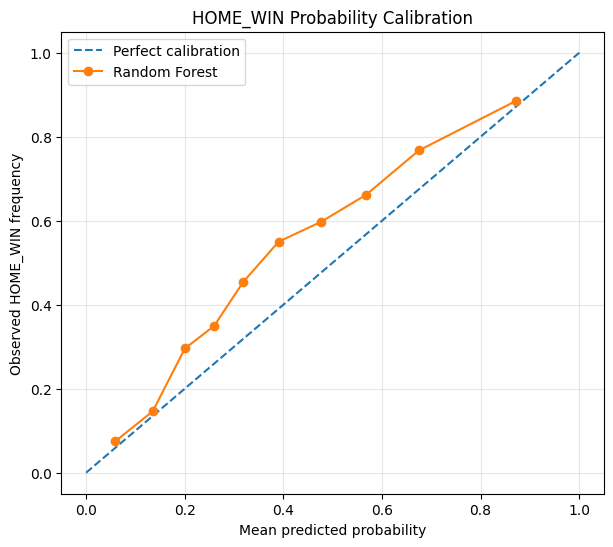

In [149]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

home_index = list(classes).index("HOME_WIN")

actual_home = (y_val == "HOME_WIN").astype(int)

prob_true, prob_pred = calibration_curve(
    actual_home,
    y_val_prob_rf[:, home_index],
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Random Forest"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed HOME_WIN frequency")
plt.title("HOME_WIN Probability Calibration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [150]:
cal_train_df = model_df[
    (model_df["date"].dt.year >= 2000) &
    (model_df["date"].dt.year <= 2016)
].copy()

calibration_df = model_df[
    (model_df["date"].dt.year >= 2017) &
    (model_df["date"].dt.year <= 2019)
].copy()

final_val_df = model_df[
    (model_df["date"].dt.year >= 2020) &
    (model_df["date"].dt.year <= 2023)
].copy()

print("Model training:", cal_train_df.shape)
print("Calibration:", calibration_df.shape)
print("Final validation:", final_val_df.shape)

Model training: (16314, 33)
Calibration: (3002, 33)
Final validation: (3486, 33)


In [151]:
X_cal_train = cal_train_df[feature_cols]
y_cal_train = cal_train_df["result"]

X_calibration = calibration_df[feature_cols]
y_calibration = calibration_df["result"]

X_final_val = final_val_df[feature_cols]
y_final_val = final_val_df["result"]

In [152]:
rf_for_calibration = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_for_calibration.fit(
    X_cal_train,
    y_cal_train
)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [154]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

calibrated_rf = CalibratedClassifierCV(
    estimator=FrozenEstimator(rf_for_calibration),
    method="sigmoid"
)

calibrated_rf.fit(
    X_calibration,
    y_calibration
)

CalibratedClassifierCV(estimator=FrozenEstimator(estimator=RandomForestClassifier(class_weight='balanced',
                                                                                  max_depth=12,
                                                                                  min_samples_leaf=5,
                                                                                  n_estimators=300,
                                                                                  n_jobs=-1,
                                                                                  random_state=42)))

In [155]:
y_val_cal_pred = calibrated_rf.predict(X_final_val)
y_val_cal_prob = calibrated_rf.predict_proba(X_final_val)


In [156]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss
)

print(
    "Accuracy:",
    accuracy_score(y_final_val, y_val_cal_pred)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(y_final_val, y_val_cal_pred)
)

print(
    "F1 Macro:",
    f1_score(
        y_final_val,
        y_val_cal_pred,
        average="macro"
    )
)

print(
    "Log Loss:",
    log_loss(
        y_final_val,
        y_val_cal_prob,
        labels=calibrated_rf.classes_
    )
)

Accuracy: 0.6035570854847964
Balanced Accuracy: 0.5087657785513667
F1 Macro: 0.471216283767158
Log Loss: 0.8828370682022034


In [157]:
classes_cal = calibrated_rf.classes_

y_val_cal_onehot = np.zeros_like(y_val_cal_prob)

for i, label in enumerate(y_final_val):

    class_index = np.where(
        classes_cal == label
    )[0][0]

    y_val_cal_onehot[i, class_index] = 1

brier_calibrated = np.mean(
    np.sum(
        (y_val_cal_prob - y_val_cal_onehot) ** 2,
        axis=1
    )
)

print("Calibrated Brier Score:", brier_calibrated)

Calibrated Brier Score: 0.5162465313067451


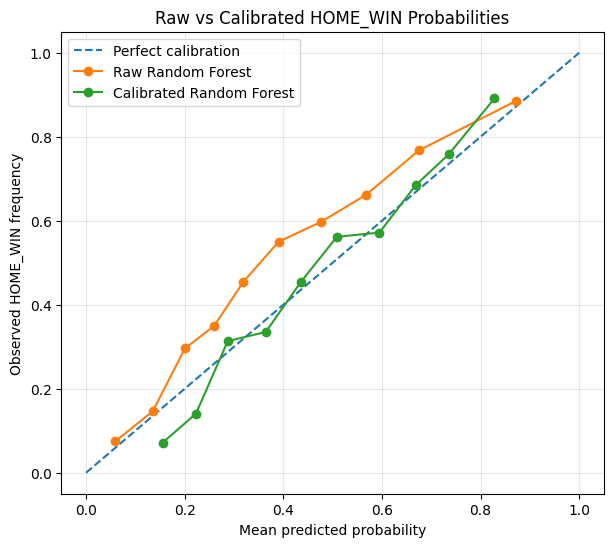

In [158]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

home_index_raw = list(rf_model.classes_).index("HOME_WIN")
home_index_cal = list(calibrated_rf.classes_).index("HOME_WIN")

actual_home = (y_final_val == "HOME_WIN").astype(int)

prob_true_raw, prob_pred_raw = calibration_curve(
    actual_home,
    y_val_prob_rf[:, home_index_raw],
    n_bins=10,
    strategy="quantile"
)

prob_true_cal, prob_pred_cal = calibration_curve(
    actual_home,
    y_val_cal_prob[:, home_index_cal],
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    prob_pred_raw,
    prob_true_raw,
    marker="o",
    label="Raw Random Forest"
)

plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    label="Calibrated Random Forest"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed HOME_WIN frequency")
plt.title("Raw vs Calibrated HOME_WIN Probabilities")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [159]:
backtest_train = model_df[
    (model_df["date"].dt.year >= 2000) &
    (model_df["date"].dt.year <= 2011)
].copy()

backtest_test = model_df[
    (model_df["date"].dt.year >= 2012) &
    (model_df["date"].dt.year <= 2014)
].copy()

X_bt_train = backtest_train[feature_cols]
y_bt_train = backtest_train["result"]

X_bt_test = backtest_test[feature_cols]
y_bt_test = backtest_test["result"]

print("Training:", X_bt_train.shape)
print("Testing:", X_bt_test.shape)
print(
    "Training years:",
    backtest_train["date"].dt.year.min(),
    "-",
    backtest_train["date"].dt.year.max()
)
print(
    "Testing years:",
    backtest_test["date"].dt.year.min(),
    "-",
    backtest_test["date"].dt.year.max()
)

Training: (11511, 13)
Testing: (2844, 13)
Training years: 2000 - 2011
Testing years: 2012 - 2014


In [160]:
rf_backtest = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_backtest.fit(X_bt_train, y_bt_train)

y_bt_pred = rf_backtest.predict(X_bt_test)
y_bt_prob = rf_backtest.predict_proba(X_bt_test)

In [161]:
print("Accuracy:",
      accuracy_score(y_bt_test, y_bt_pred))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_bt_test, y_bt_pred))

print("F1 Macro:",
      f1_score(y_bt_test, y_bt_pred, average="macro"))

print("Log Loss:",
      log_loss(
          y_bt_test,
          y_bt_prob,
          labels=rf_backtest.classes_
      ))

Accuracy: 0.5214486638537271
Balanced Accuracy: 0.4843559441344201
F1 Macro: 0.48140287109564345
Log Loss: 0.9639609244605547


In [162]:
def run_backtest(
    model_df,
    feature_cols,
    train_end_year,
    test_start_year,
    test_end_year
):

    train = model_df[
        (model_df["date"].dt.year >= 2000) &
        (model_df["date"].dt.year <= train_end_year)
    ].copy()

    test = model_df[
        (model_df["date"].dt.year >= test_start_year) &
        (model_df["date"].dt.year <= test_end_year)
    ].copy()

    X_train = train[feature_cols]
    y_train = train["result"]

    X_test = test[feature_cols]
    y_test = test["result"]

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    return {
        "train_period": f"2000-{train_end_year}",
        "test_period": f"{test_start_year}-{test_end_year}",
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_test, y_pred
        ),
        "f1_macro": f1_score(
            y_test, y_pred, average="macro"
        ),
        "log_loss": log_loss(
            y_test,
            y_prob,
            labels=model.classes_
        )
    }

In [163]:
backtest_results = []

windows = [
    (2011, 2012, 2014),
    (2014, 2015, 2017),
    (2017, 2018, 2020),
    (2020, 2021, 2023)
]

for train_end, test_start, test_end in windows:

    result = run_backtest(
        model_df,
        feature_cols,
        train_end,
        test_start,
        test_end
    )

    backtest_results.append(result)

backtest_results_df = pd.DataFrame(backtest_results)

backtest_results_df

,train_period,test_period,accuracy,balanced_accuracy,f1_macro,log_loss
0,2000-2011,2012-2014,0.521449,0.484356,0.481403,0.963961
1,2000-2014,2015-2017,0.552896,0.507011,0.501735,0.929305
2,2000-2017,2018-2020,0.550103,0.511949,0.509044,0.928178
3,2000-2020,2021-2023,0.582988,0.530300,0.523917,0.888907


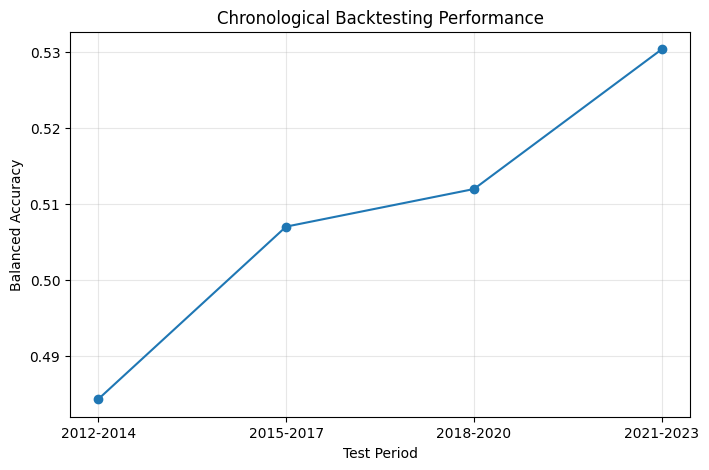

In [164]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    backtest_results_df["test_period"],
    backtest_results_df["balanced_accuracy"],
    marker="o"
)

plt.xlabel("Test Period")
plt.ylabel("Balanced Accuracy")
plt.title("Chronological Backtesting Performance")
plt.grid(alpha=0.3)

plt.show()

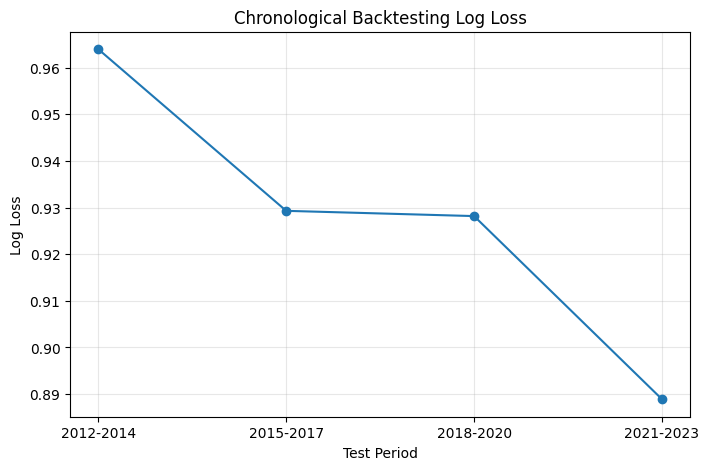

In [165]:
plt.figure(figsize=(8, 5))

plt.plot(
    backtest_results_df["test_period"],
    backtest_results_df["log_loss"],
    marker="o"
)

plt.xlabel("Test Period")
plt.ylabel("Log Loss")
plt.title("Chronological Backtesting Log Loss")
plt.grid(alpha=0.3)

plt.show()

In [166]:
final_train_df = model_df[
    model_df["date"].dt.year <= 2023
].copy()

final_test_df = model_df[
    model_df["date"].dt.year >= 2024
].copy()

X_final_train = final_train_df[feature_cols]
y_final_train = final_train_df["result"]

X_final_test = final_test_df[feature_cols]
y_final_test = final_test_df["result"]

print("Final training:", X_final_train.shape)
print("Final test:", X_final_test.shape)

print(
    "Training period:",
    final_train_df["date"].min(),
    "→",
    final_train_df["date"].max()
)

print(
    "Test period:",
    final_test_df["date"].min(),
    "→",
    final_test_df["date"].max()
)

Final training: (22802, 13)
Final test: (2683, 13)
Training period: 2000-01-04 00:00:00 → 2023-12-16 00:00:00
Test period: 2024-01-01 00:00:00 → 2026-08-26 00:00:00


In [167]:
final_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_rf.fit(
    X_final_train,
    y_final_train
)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [168]:
y_final_pred = final_rf.predict(X_final_test)

y_final_prob = final_rf.predict_proba(X_final_test)

In [169]:
print(
    "Accuracy:",
    accuracy_score(y_final_test, y_final_pred)
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(
        y_final_test,
        y_final_pred
    )
)

print(
    "F1 Macro:",
    f1_score(
        y_final_test,
        y_final_pred,
        average="macro"
    )
)

print(
    "Log Loss:",
    log_loss(
        y_final_test,
        y_final_prob,
        labels=final_rf.classes_
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_final_test,
        y_final_pred
    )
)

Accuracy: 0.5792023853894894
Balanced Accuracy: 0.5269181390640346
F1 Macro: 0.5187239506458204
Log Loss: 0.8911567771692913

Classification Report:

              precision    recall  f1-score   support

    AWAY_WIN       0.58      0.65      0.61       783
        DRAW       0.27      0.21      0.24       630
    HOME_WIN       0.70      0.72      0.71      1270

    accuracy                           0.58      2683
   macro avg       0.51      0.53      0.52      2683
weighted avg       0.56      0.58      0.57      2683



In [170]:
final_prob_train = model_df[
    (model_df["date"].dt.year >= 2000) &
    (model_df["date"].dt.year <= 2019)
].copy()

final_prob_cal = model_df[
    (model_df["date"].dt.year >= 2020) &
    (model_df["date"].dt.year <= 2023)
].copy()

final_prob_test = model_df[
    model_df["date"].dt.year >= 2024
].copy()

print("Probability training:", final_prob_train.shape)
print("Calibration:", final_prob_cal.shape)
print("Final test:", final_prob_test.shape)

Probability training: (19316, 33)
Calibration: (3486, 33)
Final test: (2683, 33)


In [171]:
X_prob_train = final_prob_train[feature_cols]
y_prob_train = final_prob_train["result"]

X_prob_cal = final_prob_cal[feature_cols]
y_prob_cal = final_prob_cal["result"]

X_prob_test = final_prob_test[feature_cols]
y_prob_test = final_prob_test["result"]

In [172]:
final_probability_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_probability_rf.fit(
    X_prob_train,
    y_prob_train
)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [173]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

final_calibrated_rf = CalibratedClassifierCV(
    estimator=FrozenEstimator(final_probability_rf),
    method="sigmoid"
)

final_calibrated_rf.fit(
    X_prob_cal,
    y_prob_cal
)

CalibratedClassifierCV(estimator=FrozenEstimator(estimator=RandomForestClassifier(class_weight='balanced',
                                                                                  max_depth=12,
                                                                                  min_samples_leaf=5,
                                                                                  n_estimators=300,
                                                                                  n_jobs=-1,
                                                                                  random_state=42)))

In [190]:
# Actual test labels — directly from the original test dataframe
final_test_actual = final_prob_test["result"].to_numpy()

# Predictions from calibrated model
final_test_predicted = final_calibrated_rf.predict(X_prob_test)

# Predicted probabilities
final_test_probabilities = final_calibrated_rf.predict_proba(X_prob_test)

print("Actual labels shape:", final_test_actual.shape)
print("Predicted labels shape:", final_test_predicted.shape)
print("Probability shape:", final_test_probabilities.shape)

print("\nActual labels example:")
print(final_test_actual[:10])

print("\nPredicted labels example:")
print(final_test_predicted[:10])

print("\nProbability example:")
print(final_test_probabilities[:3])

print("\nClasses:")
print(final_calibrated_rf.classes_)

Actual labels shape: (2683,)
Predicted labels shape: (2683,)
Probability shape: (2683, 3)

Actual labels example:
['HOME_WIN' 'AWAY_WIN' 'AWAY_WIN' 'HOME_WIN' 'HOME_WIN' 'AWAY_WIN' 'DRAW'
 'AWAY_WIN' 'AWAY_WIN' 'HOME_WIN']

Predicted labels example:
['HOME_WIN' 'HOME_WIN' 'AWAY_WIN' 'HOME_WIN' 'HOME_WIN' 'HOME_WIN'
 'AWAY_WIN' 'AWAY_WIN' 'AWAY_WIN' 'HOME_WIN']

Probability example:
[[0.06035431 0.17578127 0.76386441]
 [0.07560499 0.20070448 0.72369054]
 [0.48209878 0.2266718  0.29122943]]

Classes:
['AWAY_WIN' 'DRAW' 'HOME_WIN']


In [191]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    classification_report
)

accuracy = accuracy_score(
    final_test_actual,
    final_test_predicted
)

balanced_accuracy = balanced_accuracy_score(
    final_test_actual,
    final_test_predicted
)

f1_macro = f1_score(
    final_test_actual,
    final_test_predicted,
    average="macro"
)

logloss = log_loss(
    final_test_actual,
    final_test_probabilities,
    labels=final_calibrated_rf.classes_
)

print("FINAL TEST RESULTS")
print("-------------------")
print(f"Accuracy:           {accuracy:.4f}")
print(f"Balanced Accuracy:  {balanced_accuracy:.4f}")
print(f"Macro F1:           {f1_macro:.4f}")
print(f"Log Loss:           {logloss:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        final_test_actual,
        final_test_predicted
    )
)

FINAL TEST RESULTS
-------------------
Accuracy:           0.6045
Balanced Accuracy:  0.5168
Macro F1:           0.4696
Log Loss:           0.8794

Classification Report:
              precision    recall  f1-score   support

    AWAY_WIN       0.57      0.66      0.61       783
        DRAW       0.29      0.04      0.07       630
    HOME_WIN       0.64      0.85      0.73      1270

    accuracy                           0.60      2683
   macro avg       0.50      0.52      0.47      2683
weighted avg       0.54      0.60      0.54      2683



In [192]:
import numpy as np

classes_final = final_calibrated_rf.classes_

# Convert actual labels into one-hot format
final_test_onehot = np.zeros_like(final_test_probabilities)

for i, label in enumerate(final_test_actual):
    class_index = np.where(classes_final == label)[0][0]
    final_test_onehot[i, class_index] = 1

# Multiclass Brier Score
final_brier = np.mean(
    np.sum(
        (final_test_probabilities - final_test_onehot) ** 2,
        axis=1
    )
)

print("Final Brier Score:", round(final_brier, 4))

Final Brier Score: 0.5166


In [193]:
probability_check = final_prob_test[
    ["date", "home_team", "away_team", "result"]
].copy()

probability_check["P_AWAY_WIN"] = final_test_probabilities[:, 0]
probability_check["P_DRAW"] = final_test_probabilities[:, 1]
probability_check["P_HOME_WIN"] = final_test_probabilities[:, 2]

# Check probability sums
probability_sums = final_test_probabilities.sum(axis=1)

print("First 10 probability sums:")
print(probability_sums[:10])

print("\nMinimum probability sum:", probability_sums.min())
print("Maximum probability sum:", probability_sums.max())

print("\nFirst 10 predictions:")
display(probability_check.head(10))

First 10 probability sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Minimum probability sum: 0.9999999999999998
Maximum probability sum: 1.0000000000000002

First 10 predictions:


,date,home_team,away_team,result,P_AWAY_WIN,P_DRAW,P_HOME_WIN
22802,2024-01-01,Japan,Thailand,HOME_WIN,0.060354,0.175781,0.763864
22803,2024-01-01,China,Hong Kong,AWAY_WIN,0.075605,0.200704,0.723691
22804,2024-01-02,Indonesia,Libya,AWAY_WIN,0.482099,0.226672,0.291229
22805,2024-01-04,Tajikistan,Hong Kong,HOME_WIN,0.131575,0.317270,0.551155
22806,2024-01-04,Saudi Arabia,Lebanon,HOME_WIN,0.118066,0.260270,0.621664
22807,2024-01-05,Qatar,Jordan,AWAY_WIN,0.206444,0.320947,0.472609
22808,2024-01-05,Kyrgyzstan,Syria,DRAW,0.584028,0.199819,0.216153
22809,2024-01-05,Togo,Algeria,AWAY_WIN,0.658444,0.187435,0.154121
22810,2024-01-05,Indonesia,Libya,AWAY_WIN,0.543865,0.218464,0.237671
22811,2024-01-05,Iran,Burkina Faso,HOME_WIN,0.083551,0.159093,0.757356


In [194]:
import os
import joblib
import pandas as pd

# ============================================================
# 1. Create project folders
# ============================================================

MODEL_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/models/"
RESULTS_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/results/"

os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)


# ============================================================
# 2. Save FINAL calibrated Random Forest model
# ============================================================

joblib.dump(
    final_calibrated_rf,
    MODEL_PATH + "final_calibrated_rf.pkl"
)


# ============================================================
# 3. Save original Random Forest model
# ============================================================

joblib.dump(
    final_probability_rf,
    MODEL_PATH + "final_probability_rf.pkl"
)


# ============================================================
# 4. Save final test probabilities
# ============================================================

probability_check.to_csv(
    RESULTS_PATH + "final_test_probabilities.csv",
    index=False
)


# ============================================================
# 5. Save final test predictions
# ============================================================

final_predictions = final_prob_test[
    ["date", "home_team", "away_team", "result"]
].copy()

final_predictions["predicted_result"] = final_test_predicted
final_predictions["P_AWAY_WIN"] = final_test_probabilities[:, 0]
final_predictions["P_DRAW"] = final_test_probabilities[:, 1]
final_predictions["P_HOME_WIN"] = final_test_probabilities[:, 2]

final_predictions.to_csv(
    RESULTS_PATH + "final_test_predictions.csv",
    index=False
)


# ============================================================
# 6. Save feature list
# ============================================================

pd.DataFrame({
    "feature": feature_cols
}).to_csv(
    RESULTS_PATH + "final_feature_list.csv",
    index=False
)


# ============================================================
# 7. Save final evaluation metrics
# ============================================================

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Log Loss",
        "Brier Score"
    ],
    "Value": [
        accuracy,
        balanced_accuracy,
        f1_macro,
        logloss,
        final_brier
    ]
})

final_metrics.to_csv(
    RESULTS_PATH + "final_model_metrics.csv",
    index=False
)


# ============================================================
# 8. Save important model data
# ============================================================

print("======================================")
print("      PROJECT SAVED SUCCESSFULLY      ")
print("======================================")

print("\nMODEL FILES:")
print("✓ final_calibrated_rf.pkl")
print("✓ final_probability_rf.pkl")

print("\nRESULT FILES:")
print("✓ final_test_probabilities.csv")
print("✓ final_test_predictions.csv")
print("✓ final_feature_list.csv")
print("✓ final_model_metrics.csv")

print("\nLocation:")
print("/content/drive/MyDrive/FIFA_World_Cup_Project/")

      PROJECT SAVED SUCCESSFULLY      

MODEL FILES:
✓ final_calibrated_rf.pkl
✓ final_probability_rf.pkl

RESULT FILES:
✓ final_test_probabilities.csv
✓ final_test_predictions.csv
✓ final_feature_list.csv
✓ final_model_metrics.csv

Location:
/content/drive/MyDrive/FIFA_World_Cup_Project/


In [195]:
engineered_features = [
    "elo_difference",
    "expected_home",
    "form_difference",
    "h2h_difference",
    "goals_scored_difference",
    "goals_conceded_difference",
    "recent_gd_difference",
    "elo_ratio",
    "neutral",
    "home_advantage",
    "is_world_cup"
]

print("Checking engineered features...\n")

for feature in engineered_features:
    print(f"{feature:30} -> {feature in model_df.columns}")

print("\nTotal engineered features:", len(engineered_features))

missing_features = [
    feature for feature in engineered_features
    if feature not in model_df.columns
]

print("Missing features:", missing_features)

Checking engineered features...

elo_difference                 -> True
expected_home                  -> True
form_difference                -> True
h2h_difference                 -> True
goals_scored_difference        -> True
goals_conceded_difference      -> True
recent_gd_difference           -> True
elo_ratio                      -> True
neutral                        -> True
home_advantage                 -> True
is_world_cup                   -> True

Total engineered features: 11
Missing features: []


In [196]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# ============================================================
# STEP B1 — Split the data chronologically
# ============================================================

engineered_train = model_df[
    (model_df["date"].dt.year >= 2000) &
    (model_df["date"].dt.year <= 2019)
].copy()

engineered_calibration = model_df[
    (model_df["date"].dt.year >= 2020) &
    (model_df["date"].dt.year <= 2023)
].copy()

engineered_test = model_df[
    model_df["date"].dt.year >= 2024
].copy()


# ============================================================
# STEP B2 — Prepare X and y
# ============================================================

X_engineered_train = engineered_train[engineered_features]
y_engineered_train = engineered_train["result"]

X_engineered_calibration = engineered_calibration[engineered_features]
y_engineered_calibration = engineered_calibration["result"]

X_engineered_test = engineered_test[engineered_features]
y_engineered_test = engineered_test["result"]


# ============================================================
# STEP B3 — Train Random Forest
# ============================================================

engineered_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

engineered_rf.fit(
    X_engineered_train,
    y_engineered_train
)


# ============================================================
# STEP B4 — Calibrate probabilities
# ============================================================

engineered_calibrated_rf = CalibratedClassifierCV(
    estimator=FrozenEstimator(engineered_rf),
    method="sigmoid"
)

engineered_calibrated_rf.fit(
    X_engineered_calibration,
    y_engineered_calibration
)


# ============================================================
# STEP B5 — Generate FINAL TEST predictions
# ============================================================

engineered_test_actual = y_engineered_test.to_numpy()

engineered_test_predicted = (
    engineered_calibrated_rf.predict(X_engineered_test)
)

engineered_test_probabilities = (
    engineered_calibrated_rf.predict_proba(X_engineered_test)
)


# ============================================================
# STEP B6 — Basic verification
# ============================================================

print("Engineered model trained successfully.\n")

print("Training shape:",
      X_engineered_train.shape)

print("Calibration shape:",
      X_engineered_calibration.shape)

print("Test shape:",
      X_engineered_test.shape)

print("\nActual labels:",
      engineered_test_actual.shape)

print("Predicted labels:",
      engineered_test_predicted.shape)

print("Probabilities:",
      engineered_test_probabilities.shape)

print("\nClasses:",
      engineered_calibrated_rf.classes_)

Engineered model trained successfully.

Training shape: (19316, 11)
Calibration shape: (3486, 11)
Test shape: (2683, 11)

Actual labels: (2683,)
Predicted labels: (2683,)
Probabilities: (2683, 3)

Classes: ['AWAY_WIN' 'DRAW' 'HOME_WIN']


In [197]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    classification_report
)
import numpy as np

# ============================================================
# Classification metrics
# ============================================================

engineered_accuracy = accuracy_score(
    engineered_test_actual,
    engineered_test_predicted
)

engineered_balanced_accuracy = balanced_accuracy_score(
    engineered_test_actual,
    engineered_test_predicted
)

engineered_f1_macro = f1_score(
    engineered_test_actual,
    engineered_test_predicted,
    average="macro"
)

engineered_logloss = log_loss(
    engineered_test_actual,
    engineered_test_probabilities,
    labels=engineered_calibrated_rf.classes_
)


# ============================================================
# Brier Score
# ============================================================

engineered_classes = engineered_calibrated_rf.classes_

engineered_onehot = np.zeros_like(
    engineered_test_probabilities
)

for i, label in enumerate(engineered_test_actual):
    class_index = np.where(
        engineered_classes == label
    )[0][0]

    engineered_onehot[i, class_index] = 1

engineered_brier = np.mean(
    np.sum(
        (engineered_test_probabilities - engineered_onehot) ** 2,
        axis=1
    )
)


# ============================================================
# Print results
# ============================================================

print("ENGINEERED MODEL — FINAL TEST RESULTS")
print("--------------------------------------")

print(f"Accuracy:           {engineered_accuracy:.4f}")
print(f"Balanced Accuracy:  {engineered_balanced_accuracy:.4f}")
print(f"Macro F1:           {engineered_f1_macro:.4f}")
print(f"Log Loss:           {engineered_logloss:.4f}")
print(f"Brier Score:        {engineered_brier:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        engineered_test_actual,
        engineered_test_predicted
    )
)


ENGINEERED MODEL — FINAL TEST RESULTS
--------------------------------------
Accuracy:           0.5978
Balanced Accuracy:  0.5119
Macro F1:           0.4639
Log Loss:           0.8788
Brier Score:        0.5159

Classification Report:
              precision    recall  f1-score   support

    AWAY_WIN       0.55      0.66      0.60       783
        DRAW       0.27      0.04      0.06       630
    HOME_WIN       0.64      0.84      0.73      1270

    accuracy                           0.60      2683
   macro avg       0.49      0.51      0.46      2683
weighted avg       0.53      0.60      0.53      2683



In [198]:
print("ENGINEERED MODEL — DRAW PROBABILITY")
print("------------------------------------")

print(
    pd.Series(
        engineered_test_probabilities[:, 1],
        name="P_DRAW"
    ).describe()
)

ENGINEERED MODEL — DRAW PROBABILITY
------------------------------------
count    2683.000000
mean        0.226593
std         0.082156
min         0.062992
25%         0.162439
50%         0.233116
75%         0.286698
max         0.498608
Name: P_DRAW, dtype: float64


In [199]:
# Save the engineered calibrated model
joblib.dump(
    engineered_calibrated_rf,
    MODEL_PATH + "final_engineered_calibrated_rf.pkl"
)

# Save the engineered Random Forest before calibration
joblib.dump(
    engineered_rf,
    MODEL_PATH + "final_engineered_rf.pkl"
)

print("Engineered models saved successfully.")

Engineered models saved successfully.


In [1]:
import os
import joblib
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/data/"
MODEL_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/models/"
RESULTS_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/results/"

print("Drive connected.")

Mounted at /content/drive
Drive connected.


In [2]:
final_engineered_calibrated_rf = joblib.load(
    MODEL_PATH + "final_engineered_calibrated_rf.pkl"
)

print("Final engineered calibrated model loaded successfully.")
print("Classes:", final_engineered_calibrated_rf.classes_)

Final engineered calibrated model loaded successfully.
Classes: ['AWAY_WIN' 'DRAW' 'HOME_WIN']


In [3]:
final_predictions = pd.read_csv(
    RESULTS_PATH + "final_test_predictions.csv"
)

final_metrics = pd.read_csv(
    RESULTS_PATH + "final_model_metrics.csv"
)

print("Saved results loaded.")
display(final_metrics)

Saved results loaded.


,Metric,Value
0,Accuracy,0.604547
1,Balanced Accuracy,0.516846
2,Macro F1,0.469615
3,Log Loss,0.879379
4,Brier Score,0.516580


In [5]:
df = pd.read_csv(DATA_PATH + "results.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

df.head()

Shape: (49547, 9)
Date range: 1872-11-30 00:00:00 to 2026-08-26 00:00:00


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [6]:
df["result"] = np.select(
    [
        df["home_score"] > df["away_score"],
        df["home_score"] < df["away_score"]
    ],
    [
        "HOME_WIN",
        "AWAY_WIN"
    ],
    default="DRAW"
)

df["result"].value_counts()

,count
result,
HOME_WIN,24276
AWAY_WIN,14010
DRAW,11261


In [7]:
from collections import defaultdict, deque

In [8]:
def calculate_elo(df, initial_rating=1500, K=20, home_advantage=60):

    ratings = {}
    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        ratings.setdefault(home, initial_rating)
        ratings.setdefault(away, initial_rating)

        home_elo = ratings[home]
        away_elo = ratings[away]

        # Home advantage is applied only when match is not neutral
        effective_home_elo = (
            home_elo
            if row["neutral"]
            else home_elo + home_advantage
        )

        expected_home = 1 / (
            1 + 10 ** ((away_elo - effective_home_elo) / 400)
        )

        expected_away = 1 - expected_home

        # Actual result
        if row["home_score"] > row["away_score"]:
            actual_home = 1
            actual_away = 0

        elif row["home_score"] < row["away_score"]:
            actual_home = 0
            actual_away = 1

        else:
            actual_home = 0.5
            actual_away = 0.5

        # Margin of victory
        mov = abs(row["home_score"] - row["away_score"])

        mov_factor = (
            np.log(mov + 1)
            if mov > 0
            else 1
        )

        # Elo updates
        home_change = (
            K * mov_factor * (actual_home - expected_home)
        )

        away_change = (
            K * mov_factor * (actual_away - expected_away)
        )

        ratings[home] += home_change
        ratings[away] += away_change

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,
            "home_elo": home_elo,
            "away_elo": away_elo,
            "expected_home": expected_home,
            "expected_away": expected_away,
            "actual_home": actual_home,
            "actual_away": actual_away,
            "mov": mov
        })

    return pd.DataFrame(records), ratings

In [9]:
def calculate_recent_form(df, window=5):

    form_history = defaultdict(
        lambda: deque(maxlen=window)
    )

    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        # PRE-MATCH form
        home_form = (
            sum(form_history[home]) / len(form_history[home])
            if form_history[home]
            else 0.5
        )

        away_form = (
            sum(form_history[away]) / len(form_history[away])
            if form_history[away]
            else 0.5
        )

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,
            "home_form": home_form,
            "away_form": away_form
        })

        # Current match result
        if row["home_score"] > row["away_score"]:
            home_result = 1
            away_result = 0

        elif row["home_score"] < row["away_score"]:
            home_result = 0
            away_result = 1

        else:
            home_result = 0.5
            away_result = 0.5

        # Update history AFTER recording pre-match state
        form_history[home].append(home_result)
        form_history[away].append(away_result)

    return pd.DataFrame(records)

In [10]:
def calculate_recent_scoring(df, window=5):

    scoring_history = defaultdict(
        lambda: deque(maxlen=window)
    )

    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        if scoring_history[home]:

            home_goals_scored = np.mean(
                [x[0] for x in scoring_history[home]]
            )

            home_goals_conceded = np.mean(
                [x[1] for x in scoring_history[home]]
            )

        else:
            home_goals_scored = 0
            home_goals_conceded = 0

        if scoring_history[away]:

            away_goals_scored = np.mean(
                [x[0] for x in scoring_history[away]]
            )

            away_goals_conceded = np.mean(
                [x[1] for x in scoring_history[away]]
            )

        else:
            away_goals_scored = 0
            away_goals_conceded = 0

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,

            "home_goals_scored_avg": home_goals_scored,
            "home_goals_conceded_avg": home_goals_conceded,

            "away_goals_scored_avg": away_goals_scored,
            "away_goals_conceded_avg": away_goals_conceded
        })

        # Update AFTER calculating pre-match values
        scoring_history[home].append(
            (row["home_score"], row["away_score"])
        )

        scoring_history[away].append(
            (row["away_score"], row["home_score"])
        )

    return pd.DataFrame(records)

In [11]:
def calculate_recent_goal_difference(df, window=5):

    goal_diff_history = defaultdict(
        lambda: deque(maxlen=window)
    )

    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        home_gd = (
            np.mean(goal_diff_history[home])
            if goal_diff_history[home]
            else 0
        )

        away_gd = (
            np.mean(goal_diff_history[away])
            if goal_diff_history[away]
            else 0
        )

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,
            "home_recent_gd": home_gd,
            "away_recent_gd": away_gd
        })

        match_gd = row["home_score"] - row["away_score"]

        goal_diff_history[home].append(match_gd)
        goal_diff_history[away].append(-match_gd)

    return pd.DataFrame(records)

In [12]:
def calculate_h2h(df, window=5):

    h2h_history = defaultdict(
        lambda: deque(maxlen=window)
    )

    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        pair = tuple(sorted([home, away]))

        home_h2h = (
            sum(h2h_history[pair]) / len(h2h_history[pair])
            if h2h_history[pair]
            else 0.5
        )

        # For the current home team's perspective
        if h2h_history[pair]:

            history = h2h_history[pair]

            home_h2h = sum(history) / len(history)

            away_h2h = 1 - home_h2h

        else:

            home_h2h = 0.5
            away_h2h = 0.5

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,
            "home_h2h": home_h2h,
            "away_h2h": away_h2h
        })

        # Current match result from current home's perspective
        if row["home_score"] > row["away_score"]:
            current_result = 1

        elif row["home_score"] < row["away_score"]:
            current_result = 0

        else:
            current_result = 0.5

        # Store result from this pair's perspective.
        # If sorted first team is the current home team,
        # store current_result; otherwise store its complement.
        if home == pair[0]:
            pair_result = current_result
        else:
            pair_result = 1 - current_result

        h2h_history[pair].append(pair_result)

    return pd.DataFrame(records)

In [13]:
CUTOFF_DATE = pd.Timestamp("2026-06-01")

In [14]:
historical_df = df[
    df["date"] < CUTOFF_DATE
].copy()

historical_df = (
    historical_df
    .sort_values("date")
    .reset_index(drop=True)
)

print("Historical matches:", len(historical_df))
print("Last date:", historical_df["date"].max())

Historical matches: 49288
Last date: 2026-05-31 00:00:00


In [15]:
elo_history, current_ratings = calculate_elo(
    historical_df
)

print("Number of teams:", len(current_ratings))

Number of teams: 336


In [16]:
current_ratings.get("Brazil")

np.float64(1993.6123433110884)

In [17]:
current_ratings.get("France")

np.float64(1985.0496538807831)

In [18]:
form_history_df = calculate_recent_form(
    historical_df,
    window=5
)

team_form = {}

for _, row in form_history_df.sort_values("date").iterrows():

    team_form[row["home_team"]] = row["home_form"]
    team_form[row["away_team"]] = row["away_form"]

print("Teams with form:", len(team_form))

Teams with form: 336


In [19]:
team_form.get("Brazil")

0.5

In [20]:
scoring_history_df = calculate_recent_scoring(
    historical_df,
    window=5
)

team_scoring = {}

for _, row in scoring_history_df.sort_values("date").iterrows():

    team_scoring[row["home_team"]] = {
        "goals_scored_avg": row["home_goals_scored_avg"],
        "goals_conceded_avg": row["home_goals_conceded_avg"]
    }

    team_scoring[row["away_team"]] = {
        "goals_scored_avg": row["away_goals_scored_avg"],
        "goals_conceded_avg": row["away_goals_conceded_avg"]
    }

print("Teams with scoring state:", len(team_scoring))

Teams with scoring state: 336


In [21]:
gd_history_df = calculate_recent_goal_difference(
    historical_df,
    window=5
)

team_gd = {}

for _, row in gd_history_df.sort_values("date").iterrows():

    team_gd[row["home_team"]] = row["home_recent_gd"]
    team_gd[row["away_team"]] = row["away_recent_gd"]

print("Teams with GD state:", len(team_gd))

Teams with GD state: 336


In [22]:
team_states = {}

all_teams = set(current_ratings) | set(team_form) | set(team_scoring) | set(team_gd)

for team in all_teams:

    team_states[team] = {
        "elo": current_ratings.get(team, 1500),
        "form": team_form.get(team, 0.5),
        "goals_scored_avg": team_scoring.get(
            team, {}
        ).get("goals_scored_avg", 0),

        "goals_conceded_avg": team_scoring.get(
            team, {}
        ).get("goals_conceded_avg", 0),

        "recent_gd": team_gd.get(team, 0)
    }

In [23]:
team_states["Brazil"]

{'elo': np.float64(1993.6123433110884),
 'form': 0.5,
 'goals_scored_avg': 1.8,
 'goals_conceded_avg': 1.4,
 'recent_gd': 0.4}

In [24]:
for team in ["Brazil", "France", "Japan", "Argentina"]:

    if team in team_states:
        print(team)
        print(team_states[team])
        print()

Brazil
{'elo': np.float64(1993.6123433110884), 'form': 0.5, 'goals_scored_avg': 1.8, 'goals_conceded_avg': 1.4, 'recent_gd': 0.4}

France
{'elo': np.float64(1985.0496538807831), 'form': 0.9, 'goals_scored_avg': 2.8, 'goals_conceded_avg': 0.8, 'recent_gd': 2.0}

Japan
{'elo': np.float64(1895.864040554867), 'form': 1.0, 'goals_scored_avg': 2.0, 'goals_conceded_avg': 0.4, 'recent_gd': 1.6}

Argentina
{'elo': np.float64(2041.117211341962), 'form': 0.8, 'goals_scored_avg': 2.2, 'goals_conceded_avg': 0.4, 'recent_gd': 1.8}



In [25]:
from collections import defaultdict, deque

scoring_history = defaultdict(lambda: deque(maxlen=5))

team_scoring = {}

for _, row in historical_df.sort_values("date").iterrows():

    home = row["home_team"]
    away = row["away_team"]

    # Add the completed match to each team's history
    scoring_history[home].append(
        (row["home_score"], row["away_score"])
    )

    scoring_history[away].append(
        (row["away_score"], row["home_score"])
    )


# Calculate latest scoring state for every team
for team, history in scoring_history.items():

    if history:

        goals_scored_avg = np.mean(
            [match[0] for match in history]
        )

        goals_conceded_avg = np.mean(
            [match[1] for match in history]
        )

    else:

        goals_scored_avg = 0
        goals_conceded_avg = 0

    team_scoring[team] = {
        "goals_scored_avg": goals_scored_avg,
        "goals_conceded_avg": goals_conceded_avg
    }

In [26]:
team_scoring["Brazil"]

{'goals_scored_avg': np.float64(2.6), 'goals_conceded_avg': np.float64(1.2)}

In [27]:
for team in ["Brazil", "France", "Japan", "Argentina"]:

    if team in team_scoring:

        print(team)
        print(team_scoring[team])
        print()

Brazil
{'goals_scored_avg': np.float64(2.6), 'goals_conceded_avg': np.float64(1.2)}

France
{'goals_scored_avg': np.float64(2.8), 'goals_conceded_avg': np.float64(1.0)}

Japan
{'goals_scored_avg': np.float64(1.6), 'goals_conceded_avg': np.float64(0.0)}

Argentina
{'goals_scored_avg': np.float64(3.2), 'goals_conceded_avg': np.float64(0.2)}



In [28]:
for team in team_states:

    if team in team_scoring:

        team_states[team]["goals_scored_avg"] = (
            team_scoring[team]["goals_scored_avg"]
        )

        team_states[team]["goals_conceded_avg"] = (
            team_scoring[team]["goals_conceded_avg"]
        )

    else:

        team_states[team]["goals_scored_avg"] = 0
        team_states[team]["goals_conceded_avg"] = 0

In [29]:
print("Brazil:")
print(team_states["Brazil"])

print()

print("France:")
print(team_states["France"])

Brazil:
{'elo': np.float64(1993.6123433110884), 'form': 0.5, 'goals_scored_avg': np.float64(2.6), 'goals_conceded_avg': np.float64(1.2), 'recent_gd': 0.4}

France:
{'elo': np.float64(1985.0496538807831), 'form': 0.9, 'goals_scored_avg': np.float64(2.8), 'goals_conceded_avg': np.float64(1.0), 'recent_gd': 2.0}


In [30]:
gd_history = defaultdict(lambda: deque(maxlen=5))

team_gd = {}

for _, row in historical_df.sort_values("date").iterrows():

    home = row["home_team"]
    away = row["away_team"]

    match_gd = row["home_score"] - row["away_score"]

    # From each team's perspective
    gd_history[home].append(match_gd)
    gd_history[away].append(-match_gd)


# Calculate latest recent GD for every team
for team, history in gd_history.items():

    if history:
        recent_gd = np.mean(history)
    else:
        recent_gd = 0

    team_gd[team] = recent_gd

In [31]:
print("Brazil recent GD:", team_gd["Brazil"])
print("France recent GD:", team_gd["France"])

Brazil recent GD: 1.4
France recent GD: 1.8


In [32]:
for team in team_states:

    team_states[team]["recent_gd"] = team_gd.get(
        team,
        0
    )

In [33]:
print("Brazil:")
print(team_states["Brazil"])

print()

print("France:")
print(team_states["France"])

Brazil:
{'elo': np.float64(1993.6123433110884), 'form': 0.5, 'goals_scored_avg': np.float64(2.6), 'goals_conceded_avg': np.float64(1.2), 'recent_gd': np.float64(1.4)}

France:
{'elo': np.float64(1985.0496538807831), 'form': 0.9, 'goals_scored_avg': np.float64(2.8), 'goals_conceded_avg': np.float64(1.0), 'recent_gd': np.float64(1.8)}


In [34]:
brazil_gd = team_states["Brazil"]["recent_gd"]
france_gd = team_states["France"]["recent_gd"]

recent_gd_difference = brazil_gd - france_gd

print("Brazil recent GD:", brazil_gd)
print("France recent GD:", france_gd)
print("Recent GD difference:", recent_gd_difference)

Brazil recent GD: 1.4
France recent GD: 1.8
Recent GD difference: -0.40000000000000013


In [35]:
form_history = defaultdict(lambda: deque(maxlen=5))

for _, row in historical_df.sort_values("date").iterrows():

    home = row["home_team"]
    away = row["away_team"]

    # Determine result
    if row["home_score"] > row["away_score"]:

        home_result = 1
        away_result = 0

    elif row["home_score"] < row["away_score"]:

        home_result = 0
        away_result = 1

    else:

        home_result = 0.5
        away_result = 0.5

    # Add completed match result
    form_history[home].append(home_result)
    form_history[away].append(away_result)


# Calculate latest form AFTER the final completed match
team_form_corrected = {}

for team, history in form_history.items():

    if history:
        team_form_corrected[team] = np.mean(history)

    else:
        team_form_corrected[team] = 0.5

In [36]:
print("Brazil form:", team_form_corrected["Brazil"])
print("France form:", team_form_corrected["France"])

Brazil form: 0.7
France form: 0.9


In [37]:
for team in team_states:

    team_states[team]["form"] = team_form_corrected.get(
        team,
        0.5
    )

In [38]:
print("Brazil:")
print(team_states["Brazil"])

print()

print("France:")
print(team_states["France"])

Brazil:
{'elo': np.float64(1993.6123433110884), 'form': np.float64(0.7), 'goals_scored_avg': np.float64(2.6), 'goals_conceded_avg': np.float64(1.2), 'recent_gd': np.float64(1.4)}

France:
{'elo': np.float64(1985.0496538807831), 'form': np.float64(0.9), 'goals_scored_avg': np.float64(2.8), 'goals_conceded_avg': np.float64(1.0), 'recent_gd': np.float64(1.8)}


In [39]:
h2h_history = defaultdict(lambda: deque(maxlen=5))

for _, row in historical_df.sort_values("date").iterrows():

    home = row["home_team"]
    away = row["away_team"]

    # Create an order-independent pair
    pair = tuple(sorted([home, away]))

    # Result from current home team's perspective
    if row["home_score"] > row["away_score"]:
        current_home_result = 1

    elif row["home_score"] < row["away_score"]:
        current_home_result = 0

    else:
        current_home_result = 0.5

    # Convert result to the sorted-pair perspective
    if home == pair[0]:
        pair_result = current_home_result
    else:
        pair_result = 1 - current_home_result

    h2h_history[pair].append(pair_result)

In [40]:
def get_h2h_state(home_team, away_team):

    pair = tuple(sorted([home_team, away_team]))

    history = h2h_history.get(pair)

    if not history:
        return 0.5, 0.5

    pair_score = np.mean(history)

    # pair[0]'s perspective
    pair0_h2h = pair_score
    pair1_h2h = 1 - pair_score

    if home_team == pair[0]:

        home_h2h = pair0_h2h
        away_h2h = pair1_h2h

    else:

        home_h2h = pair1_h2h
        away_h2h = pair0_h2h

    return home_h2h, away_h2h

In [41]:
brazil_h2h, france_h2h = get_h2h_state(
    "Brazil",
    "France"
)

print("Brazil H2H vs France:", brazil_h2h)
print("France H2H vs Brazil:", france_h2h)

Brazil H2H vs France: 0.4
France H2H vs Brazil: 0.6


In [42]:
h2h_difference = brazil_h2h - france_h2h

print("H2H difference:", h2h_difference)

H2H difference: -0.19999999999999996


In [43]:
print("Number of teams:", len(team_states))

print("\nBrazil:")
print(team_states["Brazil"])

print("\nFrance:")
print(team_states["France"])

Number of teams: 336

Brazil:
{'elo': np.float64(1993.6123433110884), 'form': np.float64(0.7), 'goals_scored_avg': np.float64(2.6), 'goals_conceded_avg': np.float64(1.2), 'recent_gd': np.float64(1.4)}

France:
{'elo': np.float64(1985.0496538807831), 'form': np.float64(0.9), 'goals_scored_avg': np.float64(2.8), 'goals_conceded_avg': np.float64(1.0), 'recent_gd': np.float64(1.8)}


In [44]:
brazil_h2h, france_h2h = get_h2h_state(
    "Brazil",
    "France"
)

print("Brazil H2H:", brazil_h2h)
print("France H2H:", france_h2h)
print("H2H difference:", brazil_h2h - france_h2h)

Brazil H2H: 0.4
France H2H: 0.6
H2H difference: -0.19999999999999996


In [45]:
home_team = "Brazil"
away_team = "France"

home_state = team_states[home_team]
away_state = team_states[away_team]

home_h2h, away_h2h = get_h2h_state(
    home_team,
    away_team
)

# 1. Elo difference
elo_difference = (
    home_state["elo"] - away_state["elo"]
)

# 2. Expected home
expected_home = 1 / (
    1 + 10 ** (
        (away_state["elo"] - home_state["elo"]) / 400
    )
)

# 3. Form difference
form_difference = (
    home_state["form"] - away_state["form"]
)

# 4. H2H difference
h2h_difference = (
    home_h2h - away_h2h
)

# 5. Goals scored difference
goals_scored_difference = (
    home_state["goals_scored_avg"]
    - away_state["goals_scored_avg"]
)

# 6. Goals conceded difference
goals_conceded_difference = (
    home_state["goals_conceded_avg"]
    - away_state["goals_conceded_avg"]
)

# 7. Recent GD difference
recent_gd_difference = (
    home_state["recent_gd"]
    - away_state["recent_gd"]
)

# 8. Elo ratio
elo_ratio = (
    home_state["elo"] / away_state["elo"]
)

# 9. Neutral World Cup venue
neutral = 1

# 10. Home advantage
home_advantage = 0

# 11. World Cup indicator
is_world_cup = 1

print("elo_difference:", elo_difference)
print("expected_home:", expected_home)
print("form_difference:", form_difference)
print("h2h_difference:", h2h_difference)
print("goals_scored_difference:", goals_scored_difference)
print("goals_conceded_difference:", goals_conceded_difference)
print("recent_gd_difference:", recent_gd_difference)
print("elo_ratio:", elo_ratio)
print("neutral:", neutral)
print("home_advantage:", home_advantage)
print("is_world_cup:", is_world_cup)

elo_difference: 8.562689430305227
expected_home: 0.5123202063359674
form_difference: -0.20000000000000007
h2h_difference: -0.19999999999999996
goals_scored_difference: -0.19999999999999973
goals_conceded_difference: 0.19999999999999996
recent_gd_difference: -0.40000000000000013
elo_ratio: 1.0043135895434985
neutral: 1
home_advantage: 0
is_world_cup: 1


In [46]:
match_features = pd.DataFrame([{
    "elo_difference": elo_difference,
    "expected_home": expected_home,
    "form_difference": form_difference,
    "h2h_difference": h2h_difference,
    "goals_scored_difference": goals_scored_difference,
    "goals_conceded_difference": goals_conceded_difference,
    "recent_gd_difference": recent_gd_difference,
    "elo_ratio": elo_ratio,
    "neutral": neutral,
    "home_advantage": home_advantage,
    "is_world_cup": is_world_cup
}])

match_features

,elo_difference,expected_home,form_difference,h2h_difference,goals_scored_difference,goals_conceded_difference,recent_gd_difference,elo_ratio,neutral,home_advantage,is_world_cup
0,8.562689,0.51232,-0.2,-0.2,-0.2,0.2,-0.4,1.004314,1,0,1


In [47]:
engineered_features = [
    "elo_difference",
    "expected_home",
    "form_difference",
    "h2h_difference",
    "goals_scored_difference",
    "goals_conceded_difference",
    "recent_gd_difference",
    "elo_ratio",
    "neutral",
    "home_advantage",
    "is_world_cup"
]

match_features = match_features[
    engineered_features
]

print(match_features.columns.tolist())

['elo_difference', 'expected_home', 'form_difference', 'h2h_difference', 'goals_scored_difference', 'goals_conceded_difference', 'recent_gd_difference', 'elo_ratio', 'neutral', 'home_advantage', 'is_world_cup']


In [48]:
print(final_engineered_calibrated_rf.classes_)

['AWAY_WIN' 'DRAW' 'HOME_WIN']


In [49]:
def predict_match(home_team, away_team):

    # -----------------------------
    # 1. Get team states
    # -----------------------------

    home_state = team_states[home_team]
    away_state = team_states[away_team]


    # -----------------------------
    # 2. Get H2H state
    # -----------------------------

    home_h2h, away_h2h = get_h2h_state(
        home_team,
        away_team
    )


    # -----------------------------
    # 3. Construct model features
    # -----------------------------

    elo_difference = (
        home_state["elo"]
        - away_state["elo"]
    )

    expected_home = 1 / (
        1 + 10 ** (
            (away_state["elo"] - home_state["elo"]) / 400
        )
    )

    form_difference = (
        home_state["form"]
        - away_state["form"]
    )

    h2h_difference = (
        home_h2h - away_h2h
    )

    goals_scored_difference = (
        home_state["goals_scored_avg"]
        - away_state["goals_scored_avg"]
    )

    goals_conceded_difference = (
        home_state["goals_conceded_avg"]
        - away_state["goals_conceded_avg"]
    )

    recent_gd_difference = (
        home_state["recent_gd"]
        - away_state["recent_gd"]
    )

    elo_ratio = (
        home_state["elo"]
        / away_state["elo"]
    )

    # World Cup matches are treated as neutral
    neutral = 1

    home_advantage = 0

    is_world_cup = 1


    # -----------------------------
    # 4. Create feature DataFrame
    # -----------------------------

    match_features = pd.DataFrame([{
        "elo_difference": elo_difference,
        "expected_home": expected_home,
        "form_difference": form_difference,
        "h2h_difference": h2h_difference,
        "goals_scored_difference": goals_scored_difference,
        "goals_conceded_difference": goals_conceded_difference,
        "recent_gd_difference": recent_gd_difference,
        "elo_ratio": elo_ratio,
        "neutral": neutral,
        "home_advantage": home_advantage,
        "is_world_cup": is_world_cup
    }])


    # Ensure exact training feature order
    match_features = match_features[
        engineered_features
    ]


    # -----------------------------
    # 5. Get probabilities
    # -----------------------------

    probabilities = (
        final_engineered_calibrated_rf
        .predict_proba(match_features)[0]
    )


    # -----------------------------
    # 6. Map probabilities to classes
    # -----------------------------

    probability_dict = dict(
        zip(
            final_engineered_calibrated_rf.classes_,
            probabilities
        )
    )


    return probability_dict

In [50]:
probabilities = predict_match(
    "Brazil",
    "France"
)

print(probabilities)

{'AWAY_WIN': np.float64(0.3589250841832544), 'DRAW': np.float64(0.3051822022282991), 'HOME_WIN': np.float64(0.3358927135884465)}


In [51]:
print("Brazil vs France")
print()

print(
    f"Brazil win: "
    f"{probabilities['HOME_WIN']:.4f}"
)

print(
    f"Draw: "
    f"{probabilities['DRAW']:.4f}"
)

print(
    f"France win: "
    f"{probabilities['AWAY_WIN']:.4f}"
)

print()

print(
    "Probability sum:",
    sum(probabilities.values())
)

Brazil vs France

Brazil win: 0.3359
Draw: 0.3052
France win: 0.3589

Probability sum: 1.0


In [52]:
assert all(
    0 <= probability <= 1
    for probability in probabilities.values()
)

assert np.isclose(
    sum(probabilities.values()),
    1.0
)

print("Probability validation passed.")

Probability validation passed.


In [53]:
test_matches = [
    ("Brazil", "France"),
    ("Brazil", "Japan"),
    ("France", "Japan")
]

for home_team, away_team in test_matches:

    probs = predict_match(
        home_team,
        away_team
    )

    print(
        f"{home_team} vs {away_team}"
    )

    print(
        f"  Home: {probs['HOME_WIN']:.3f}"
    )

    print(
        f"  Draw: {probs['DRAW']:.3f}"
    )

    print(
        f"  Away: {probs['AWAY_WIN']:.3f}"
    )

    print()

Brazil vs France
  Home: 0.336
  Draw: 0.305
  Away: 0.359

Brazil vs Japan
  Home: 0.477
  Draw: 0.270
  Away: 0.253

France vs Japan
  Home: 0.453
  Draw: 0.313
  Away: 0.234



In [54]:
def simulate_match(home_probability, draw_probability, away_probability):

    outcomes = [
        "HOME_WIN",
        "DRAW",
        "AWAY_WIN"
    ]

    probabilities = [
        home_probability,
        draw_probability,
        away_probability
    ]

    return np.random.choice(
        outcomes,
        p=probabilities
    )

In [55]:
result = simulate_match(
    probabilities["HOME_WIN"],
    probabilities["DRAW"],
    probabilities["AWAY_WIN"]
)

print("Simulated result:", result)

Simulated result: HOME_WIN


In [56]:
simulation_results = []

for _ in range(10):

    result = simulate_match(
        probabilities["HOME_WIN"],
        probabilities["DRAW"],
        probabilities["AWAY_WIN"]
    )

    simulation_results.append(result)

print(simulation_results)

[np.str_('DRAW'), np.str_('DRAW'), np.str_('AWAY_WIN'), np.str_('HOME_WIN'), np.str_('AWAY_WIN'), np.str_('DRAW'), np.str_('HOME_WIN'), np.str_('AWAY_WIN'), np.str_('DRAW'), np.str_('HOME_WIN')]


In [57]:
simulation_results = []

for _ in range(10000):

    result = simulate_match(
        probabilities["HOME_WIN"],
        probabilities["DRAW"],
        probabilities["AWAY_WIN"]
    )

    simulation_results.append(result)

simulation_counts = pd.Series(
    simulation_results
).value_counts()

simulation_proportions = (
    simulation_counts / len(simulation_results)
)

print(simulation_proportions)

AWAY_WIN    0.3551
HOME_WIN    0.3466
DRAW        0.2983
Name: count, dtype: float64


In [58]:
comparison = pd.DataFrame({
    "Model Probability": {
        "HOME_WIN": probabilities["HOME_WIN"],
        "DRAW": probabilities["DRAW"],
        "AWAY_WIN": probabilities["AWAY_WIN"]
    },

    "Simulation Proportion": {
        "HOME_WIN": simulation_proportions.get(
            "HOME_WIN", 0
        ),

        "DRAW": simulation_proportions.get(
            "DRAW", 0
        ),

        "AWAY_WIN": simulation_proportions.get(
            "AWAY_WIN", 0
        )
    }
})

comparison

,Model Probability,Simulation Proportion
HOME_WIN,0.335893,0.3466
DRAW,0.305182,0.2983
AWAY_WIN,0.358925,0.3551


In [59]:
from itertools import combinations

In [68]:
test_group = ["Brazil", "France", "Japan", "United States"]

print("Teams:", test_group)

Teams: ['Brazil', 'France', 'Japan', 'United States']


In [69]:
from itertools import combinations

fixtures = list(combinations(test_group, 2))

print("Number of fixtures:", len(fixtures))
print(fixtures)

Number of fixtures: 6
[('Brazil', 'France'), ('Brazil', 'Japan'), ('Brazil', 'United States'), ('France', 'Japan'), ('France', 'United States'), ('Japan', 'United States')]


In [70]:
standings = {}

for team in test_group:
    standings[team] = {
        "played": 0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "points": 0
    }

standings

{'Brazil': {'played': 0, 'wins': 0, 'draws': 0, 'losses': 0, 'points': 0},
 'France': {'played': 0, 'wins': 0, 'draws': 0, 'losses': 0, 'points': 0},
 'Japan': {'played': 0, 'wins': 0, 'draws': 0, 'losses': 0, 'points': 0},
 'United States': {'played': 0,
  'wins': 0,
  'draws': 0,
  'losses': 0,
  'points': 0}}

In [71]:
def update_standings(standings, home_team, away_team, result):

    standings[home_team]["played"] += 1
    standings[away_team]["played"] += 1

    if result == "HOME_WIN":

        standings[home_team]["wins"] += 1
        standings[home_team]["points"] += 3

        standings[away_team]["losses"] += 1

    elif result == "DRAW":

        standings[home_team]["draws"] += 1
        standings[away_team]["draws"] += 1

        standings[home_team]["points"] += 1
        standings[away_team]["points"] += 1

    elif result == "AWAY_WIN":

        standings[away_team]["wins"] += 1
        standings[away_team]["points"] += 3

        standings[home_team]["losses"] += 1

In [72]:
for home_team, away_team in fixtures:

    probabilities = predict_match(home_team, away_team)

    result = simulate_match(
        probabilities["HOME_WIN"],
        probabilities["DRAW"],
        probabilities["AWAY_WIN"]
    )

    update_standings(
        standings,
        home_team,
        away_team,
        result
    )

print(standings)

{'Brazil': {'played': 3, 'wins': 2, 'draws': 1, 'losses': 0, 'points': 7}, 'France': {'played': 3, 'wins': 0, 'draws': 2, 'losses': 1, 'points': 2}, 'Japan': {'played': 3, 'wins': 1, 'draws': 1, 'losses': 1, 'points': 4}, 'United States': {'played': 3, 'wins': 1, 'draws': 0, 'losses': 2, 'points': 3}}


In [73]:
standings_table = pd.DataFrame.from_dict(
    standings,
    orient="index"
)

standings_table = standings_table.sort_values(
    by="points",
    ascending=False
)

standings_table

,played,wins,draws,losses,points
Brazil,3,2,1,0,7
Japan,3,1,1,1,4
United States,3,1,0,2,3
France,3,0,2,1,2


In [74]:
print(standings_table["played"])

Brazil           3
Japan            3
United States    3
France           3
Name: played, dtype: int64


In [75]:
print("Total points:", standings_table["points"].sum())

Total points: 16


In [76]:
def simulate_group(teams):

    # Generate all fixtures
    fixtures = list(combinations(teams, 2))

    # Create fresh standings
    standings = {}

    for team in teams:
        standings[team] = {
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "points": 0
        }

    # Simulate every match
    for home_team, away_team in fixtures:

        probabilities = predict_match(
            home_team,
            away_team
        )

        result = simulate_match(
            probabilities["HOME_WIN"],
            probabilities["DRAW"],
            probabilities["AWAY_WIN"]
        )

        update_standings(
            standings,
            home_team,
            away_team,
            result
        )

    # Convert standings to DataFrame
    standings_table = pd.DataFrame.from_dict(
        standings,
        orient="index"
    )

    # Sort by points
    standings_table = standings_table.sort_values(
        by="points",
        ascending=False
    )

    return standings_table

In [77]:
test_group = [
    "Brazil",
    "France",
    "Japan",
    "United States"
]

group_table = simulate_group(test_group)

group_table

,played,wins,draws,losses,points
Brazil,3,1,2,0,5
France,3,1,1,1,4
Japan,3,1,1,1,4
United States,3,0,2,1,2


In [78]:
print("All teams played 3 matches:",
      (group_table["played"] == 3).all())

All teams played 3 matches: True


In [79]:
print("Number of teams:", len(group_table))

Number of teams: 4


In [80]:
print("Total group points:",
      group_table["points"].sum())

Total group points: 15


In [81]:
def simulate_score(home_team, away_team, result):

    home_state = team_states[home_team]
    away_state = team_states[away_team]

    home_attack = home_state["goals_scored_avg"]
    home_defense = home_state["goals_conceded_avg"]

    away_attack = away_state["goals_scored_avg"]
    away_defense = away_state["goals_conceded_avg"]

    home_lambda = (home_attack + away_defense) / 2
    away_lambda = (away_attack + home_defense) / 2

    home_goals = np.random.poisson(home_lambda)
    away_goals = np.random.poisson(away_lambda)

    if result == "HOME_WIN":

        while home_goals <= away_goals:
            home_goals = np.random.poisson(home_lambda)

    elif result == "AWAY_WIN":

        while away_goals <= home_goals:
            away_goals = np.random.poisson(away_lambda)

    elif result == "DRAW":

        while home_goals != away_goals:
            home_goals = np.random.poisson(home_lambda)
            away_goals = np.random.poisson(away_lambda)

    return home_goals, away_goals

In [82]:
test_result = simulate_match(
    probabilities["HOME_WIN"],
    probabilities["DRAW"],
    probabilities["AWAY_WIN"]
)

print("Result:", test_result)

home_goals, away_goals = simulate_score(
    "Brazil",
    "France",
    test_result
)

print("Brazil:", home_goals)
print("France:", away_goals)

Result: DRAW
Brazil: 2
France: 2


In [83]:
if test_result == "HOME_WIN":
    print(home_goals > away_goals)

elif test_result == "DRAW":
    print(home_goals == away_goals)

elif test_result == "AWAY_WIN":
    print(home_goals < away_goals)

True


In [84]:
def update_standings(
    standings,
    home_team,
    away_team,
    result,
    home_goals,
    away_goals
):

    # Matches played
    standings[home_team]["played"] += 1
    standings[away_team]["played"] += 1

    # Goals
    standings[home_team]["goals_for"] += home_goals
    standings[home_team]["goals_against"] += away_goals

    standings[away_team]["goals_for"] += away_goals
    standings[away_team]["goals_against"] += home_goals

    # Result
    if result == "HOME_WIN":

        standings[home_team]["wins"] += 1
        standings[home_team]["points"] += 3

        standings[away_team]["losses"] += 1

    elif result == "DRAW":

        standings[home_team]["draws"] += 1
        standings[away_team]["draws"] += 1

        standings[home_team]["points"] += 1
        standings[away_team]["points"] += 1

    elif result == "AWAY_WIN":

        standings[away_team]["wins"] += 1
        standings[away_team]["points"] += 3

        standings[home_team]["losses"] += 1

In [85]:
test_standings = {
    "Brazil": {
        "played": 0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "goals_for": 0,
        "goals_against": 0,
        "points": 0
    },
    "France": {
        "played": 0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "goals_for": 0,
        "goals_against": 0,
        "points": 0
    }
}

In [86]:
update_standings(
    test_standings,
    "Brazil",
    "France",
    "HOME_WIN",
    2,
    1
)

test_standings

{'Brazil': {'played': 1,
  'wins': 1,
  'draws': 0,
  'losses': 0,
  'goals_for': 2,
  'goals_against': 1,
  'points': 3},
 'France': {'played': 1,
  'wins': 0,
  'draws': 0,
  'losses': 1,
  'goals_for': 1,
  'goals_against': 2,
  'points': 0}}

In [87]:
test_standings = {
    "Brazil": {
        "played": 0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "goals_for": 0,
        "goals_against": 0,
        "points": 0
    },
    "France": {
        "played": 0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "goals_for": 0,
        "goals_against": 0,
        "points": 0
    }
}

In [88]:
update_standings(
    test_standings,
    "Brazil",
    "France",
    "DRAW",
    2,
    2
)

test_standings

{'Brazil': {'played': 1,
  'wins': 0,
  'draws': 1,
  'losses': 0,
  'goals_for': 2,
  'goals_against': 2,
  'points': 1},
 'France': {'played': 1,
  'wins': 0,
  'draws': 1,
  'losses': 0,
  'goals_for': 2,
  'goals_against': 2,
  'points': 1}}

In [89]:
for team in test_standings:

    test_standings[team]["goal_difference"] = (
        test_standings[team]["goals_for"]
        - test_standings[team]["goals_against"]
    )

test_standings

{'Brazil': {'played': 1,
  'wins': 0,
  'draws': 1,
  'losses': 0,
  'goals_for': 2,
  'goals_against': 2,
  'points': 1,
  'goal_difference': 0},
 'France': {'played': 1,
  'wins': 0,
  'draws': 1,
  'losses': 0,
  'goals_for': 2,
  'goals_against': 2,
  'points': 1,
  'goal_difference': 0}}

In [90]:
def simulate_group(teams):

    # Generate all fixtures
    fixtures = list(combinations(teams, 2))

    # Create fresh standings
    standings = {}

    for team in teams:

        standings[team] = {
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "points": 0
        }

    # Simulate every match
    for home_team, away_team in fixtures:

        # Get ML probabilities
        probabilities = predict_match(
            home_team,
            away_team
        )

        # Simulate match result
        result = simulate_match(
            probabilities["HOME_WIN"],
            probabilities["DRAW"],
            probabilities["AWAY_WIN"]
        )

        # Generate score consistent with result
        home_goals, away_goals = simulate_score(
            home_team,
            away_team,
            result
        )

        # Update standings
        update_standings(
            standings,
            home_team,
            away_team,
            result,
            home_goals,
            away_goals
        )

    # Convert to DataFrame
    standings_table = pd.DataFrame.from_dict(
        standings,
        orient="index"
    )

    # Calculate goal difference
    standings_table["goal_difference"] = (
        standings_table["goals_for"]
        - standings_table["goals_against"]
    )

    # Sort by points, then goal difference, then goals scored
    standings_table = standings_table.sort_values(
        by=["points", "goal_difference", "goals_for"],
        ascending=[False, False, False]
    )

    return standings_table

In [91]:
test_group = [
    "Brazil",
    "France",
    "Japan",
    "United States"
]

group_table = simulate_group(test_group)

group_table

,played,wins,draws,losses,goals_for,goals_against,points,goal_difference
Brazil,3,3,0,0,12,8,9,4
Japan,3,1,1,1,7,8,4,-1
United States,3,1,0,2,6,7,3,-1
France,3,0,1,2,7,9,1,-2


In [92]:
group_table[
    [
        "played",
        "wins",
        "draws",
        "losses",
        "goals_for",
        "goals_against",
        "goal_difference",
        "points"
    ]
]

,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
Brazil,3,3,0,0,12,8,4,9
Japan,3,1,1,1,7,8,-1,4
United States,3,1,0,2,6,7,-1,3
France,3,0,1,2,7,9,-2,1


In [93]:
groups = {
    "A": ["Mexico", "South Africa", "South Korea", "European Play-off D"],
    "B": ["Canada", "European Play-off A", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "European Play-off C"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "European Play-off B", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Intercontinental Play-off 2", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "Intercontinental Play-off 1", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"]
}

print(groups)

{'A': ['Mexico', 'South Africa', 'South Korea', 'European Play-off D'], 'B': ['Canada', 'European Play-off A', 'Qatar', 'Switzerland'], 'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'], 'D': ['United States', 'Paraguay', 'Australia', 'European Play-off C'], 'E': ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador'], 'F': ['Netherlands', 'Japan', 'European Play-off B', 'Tunisia'], 'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'], 'H': ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay'], 'I': ['France', 'Senegal', 'Intercontinental Play-off 2', 'Norway'], 'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'], 'K': ['Portugal', 'Intercontinental Play-off 1', 'Uzbekistan', 'Colombia'], 'L': ['England', 'Croatia', 'Ghana', 'Panama']}


In [94]:
print("Number of groups:", len(groups))

for group_name, teams in groups.items():
    print(
        f"Group {group_name}: "
        f"{len(teams)} teams → {teams}"
    )

Number of groups: 12
Group A: 4 teams → ['Mexico', 'South Africa', 'South Korea', 'European Play-off D']
Group B: 4 teams → ['Canada', 'European Play-off A', 'Qatar', 'Switzerland']
Group C: 4 teams → ['Brazil', 'Morocco', 'Haiti', 'Scotland']
Group D: 4 teams → ['United States', 'Paraguay', 'Australia', 'European Play-off C']
Group E: 4 teams → ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador']
Group F: 4 teams → ['Netherlands', 'Japan', 'European Play-off B', 'Tunisia']
Group G: 4 teams → ['Belgium', 'Egypt', 'Iran', 'New Zealand']
Group H: 4 teams → ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay']
Group I: 4 teams → ['France', 'Senegal', 'Intercontinental Play-off 2', 'Norway']
Group J: 4 teams → ['Argentina', 'Algeria', 'Austria', 'Jordan']
Group K: 4 teams → ['Portugal', 'Intercontinental Play-off 1', 'Uzbekistan', 'Colombia']
Group L: 4 teams → ['England', 'Croatia', 'Ghana', 'Panama']


In [95]:
total_slots = sum(len(teams) for teams in groups.values())

print("Total team slots:", total_slots)

Total team slots: 48


In [96]:
groups = {
    "A": ["Mexico", "South Africa", "South Korea", "Czechia"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Türkiye"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"]
}

print("Groups:", len(groups))

Groups: 12


In [97]:
total_slots = sum(len(teams) for teams in groups.values())

print("Total team slots:", total_slots)

for group_name, teams in groups.items():
    print(f"Group {group_name}: {teams}")

Total team slots: 48
Group A: ['Mexico', 'South Africa', 'South Korea', 'Czechia']
Group B: ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland']
Group C: ['Brazil', 'Morocco', 'Haiti', 'Scotland']
Group D: ['United States', 'Paraguay', 'Australia', 'Türkiye']
Group E: ['Germany', 'Curaçao', 'Ivory Coast', 'Ecuador']
Group F: ['Netherlands', 'Japan', 'Sweden', 'Tunisia']
Group G: ['Belgium', 'Egypt', 'Iran', 'New Zealand']
Group H: ['Spain', 'Cape Verde', 'Saudi Arabia', 'Uruguay']
Group I: ['France', 'Senegal', 'Iraq', 'Norway']
Group J: ['Argentina', 'Algeria', 'Austria', 'Jordan']
Group K: ['Portugal', 'DR Congo', 'Uzbekistan', 'Colombia']
Group L: ['England', 'Croatia', 'Ghana', 'Panama']


In [98]:
for group_name, teams in groups.items():

    print(f"\nGroup {group_name}")

    for team in teams:

        if team in team_states:
            print("✅", team)
        else:
            print("❌", team)


Group A
✅ Mexico
✅ South Africa
✅ South Korea
❌ Czechia

Group B
✅ Canada
✅ Bosnia and Herzegovina
✅ Qatar
✅ Switzerland

Group C
✅ Brazil
✅ Morocco
✅ Haiti
✅ Scotland

Group D
✅ United States
✅ Paraguay
✅ Australia
❌ Türkiye

Group E
✅ Germany
✅ Curaçao
✅ Ivory Coast
✅ Ecuador

Group F
✅ Netherlands
✅ Japan
✅ Sweden
✅ Tunisia

Group G
✅ Belgium
✅ Egypt
✅ Iran
✅ New Zealand

Group H
✅ Spain
✅ Cape Verde
✅ Saudi Arabia
✅ Uruguay

Group I
✅ France
✅ Senegal
✅ Iraq
✅ Norway

Group J
✅ Argentina
✅ Algeria
✅ Austria
✅ Jordan

Group K
✅ Portugal
✅ DR Congo
✅ Uzbekistan
✅ Colombia

Group L
✅ England
✅ Croatia
✅ Ghana
✅ Panama


In [99]:
print("Czech-related names:")
print([x for x in team_states.keys() if "Czech" in x])

print("\nTurkey-related names:")
print([x for x in team_states.keys() if "Turk" in x or "Türkiye" in x])

Czech-related names:
['Czech Republic', 'Czechoslovakia']

Turkey-related names:
['East Turkestan', 'Turkey', 'Turkmenistan', 'Turks and Caicos Islands']


In [100]:
groups = {
    "A": ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"]
}

In [101]:
missing_teams = []

for group_name, teams in groups.items():
    for team in teams:
        if team not in team_states:
            missing_teams.append(team)

print("Number of groups:", len(groups))
print("Total teams:", sum(len(teams) for teams in groups.values()))
print("Missing teams:", missing_teams)

if not missing_teams:
    print("✅ All 48 teams are valid!")

Number of groups: 12
Total teams: 48
Missing teams: []
✅ All 48 teams are valid!


In [102]:
all_group_results = {}

for group_name, teams in groups.items():
    all_group_results[group_name] = simulate_group(teams)

print("✅ Group stage simulation completed.")

✅ Group stage simulation completed.


In [103]:
for group_name, table in all_group_results.items():

    print(f"\n{'='*50}")
    print(f"GROUP {group_name}")
    print(f"{'='*50}")

    display(
        table[
            [
                "played",
                "wins",
                "draws",
                "losses",
                "goals_for",
                "goals_against",
                "goal_difference",
                "points"
            ]
        ]
    )


GROUP A


,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
Mexico,3,2,1,0,6,1,5,7
South Korea,3,1,2,0,4,2,2,5
Czech Republic,3,1,1,1,4,4,0,4
South Africa,3,0,0,3,1,8,-7,0



GROUP B


,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
Canada,3,2,1,0,2,0,2,7
Bosnia and Herzegovina,3,1,2,0,3,2,1,5
Switzerland,3,0,2,1,3,4,-1,2
Qatar,3,0,1,2,3,5,-2,1



GROUP C


...

,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
Argentina,3,1,2,0,5,3,2,5
Algeria,3,0,3,0,4,4,0,3
Austria,3,0,3,0,4,4,0,3
Jordan,3,0,2,1,5,7,-2,2



GROUP K


,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
Portugal,3,3,0,0,5,0,5,9
Colombia,3,2,0,1,5,4,1,6
DR Congo,3,1,0,2,4,6,-2,3
Uzbekistan,3,0,0,3,2,6,-4,0



GROUP L


,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
England,3,3,0,0,9,2,7,9
Croatia,3,2,0,1,8,4,4,6
Panama,3,1,0,2,5,6,-1,3
Ghana,3,0,0,3,0,10,-10,0


In [104]:
valid = True

for group_name, table in all_group_results.items():

    if len(table) != 4:
        print(f"❌ Group {group_name} does not have 4 teams")
        valid = False

    if not all(table["played"] == 3):
        print(f"❌ Group {group_name} has incorrect match counts")
        valid = False

if valid:
    print("✅ All 12 groups simulated correctly.")
    print("✅ 48 teams processed.")
    print("✅ Every team played 3 matches.")

✅ All 12 groups simulated correctly.
✅ 48 teams processed.
✅ Every team played 3 matches.


In [105]:
group_winners = {}
group_runners_up = {}
third_place_teams = []

for group_name, table in all_group_results.items():

    group_winners[group_name] = table.index[0]
    group_runners_up[group_name] = table.index[1]

    third_team = table.index[2]

    third_place_teams.append({
        "group": group_name,
        "team": third_team,
        "points": table.loc[third_team, "points"],
        "goal_difference": table.loc[third_team, "goal_difference"],
        "goals_for": table.loc[third_team, "goals_for"]
    })

third_place_df = pd.DataFrame(third_place_teams)

third_place_df = third_place_df.sort_values(
    by=["points", "goal_difference", "goals_for"],
    ascending=[False, False, False]
).reset_index(drop=True)

best_thirds = third_place_df.head(8)

In [106]:
print("GROUP WINNERS")
print("----------------")

for group, team in group_winners.items():
    print(f"{group}: {team}")

print("\nGROUP RUNNERS-UP")
print("----------------")

for group, team in group_runners_up.items():
    print(f"{group}: {team}")

print("\nBEST 8 THIRD-PLACE TEAMS")
print("----------------")

display(best_thirds)

GROUP WINNERS
----------------
A: Mexico
B: Canada
C: Scotland
D: Paraguay
E: Ecuador
F: Netherlands
G: Iran
H: Spain
I: Norway
J: Argentina
K: Portugal
L: England

GROUP RUNNERS-UP
----------------
A: South Korea
B: Bosnia and Herzegovina
C: Haiti
D: Australia
E: Germany
F: Tunisia
G: Egypt
H: Cape Verde
I: France
J: Algeria
K: Colombia
L: Croatia

BEST 8 THIRD-PLACE TEAMS
----------------


,group,team,points,goal_difference,goals_for
0,I,Senegal,4,0,5
1,A,Czech Republic,4,0,4
2,D,Turkey,4,0,3
3,G,New Zealand,4,-1,7
4,E,Ivory Coast,4,-2,5
5,C,Morocco,3,2,10
6,J,Austria,3,0,4
7,L,Panama,3,-1,5


In [107]:
qualified_teams = []

qualified_teams.extend(group_winners.values())
qualified_teams.extend(group_runners_up.values())
qualified_teams.extend(best_thirds["team"].tolist())

print("Total qualified teams:", len(qualified_teams))
print("Unique qualified teams:", len(set(qualified_teams)))

assert len(qualified_teams) == 32
assert len(set(qualified_teams)) == 32

print("✅ 32 unique teams qualified for the knockout stage.")

Total qualified teams: 32
Unique qualified teams: 32
✅ 32 unique teams qualified for the knockout stage.


In [108]:
print("QUALIFIED TEAMS")
print("=" * 50)

for i, team in enumerate(qualified_teams, start=1):
    print(f"{i:2}. {team}")

QUALIFIED TEAMS
 1. Mexico
 2. Canada
 3. Scotland
 4. Paraguay
 5. Ecuador
 6. Netherlands
 7. Iran
 8. Spain
 9. Norway
10. Argentina
11. Portugal
12. England
13. South Korea
14. Bosnia and Herzegovina
15. Haiti
16. Australia
17. Germany
18. Tunisia
19. Egypt
20. Cape Verde
21. France
22. Algeria
23. Colombia
24. Croatia
25. Senegal
26. Czech Republic
27. Turkey
28. New Zealand
29. Ivory Coast
30. Morocco
31. Austria
32. Panama


In [109]:
knockout_teams = qualified_teams.copy()

print("Knockout teams:", len(knockout_teams))

Knockout teams: 32


In [110]:
assert len(knockout_teams) == 32
assert len(set(knockout_teams)) == 32

print("✅ Round-of-32 pool ready.")
print("✅ 32 unique teams.")

✅ Round-of-32 pool ready.
✅ 32 unique teams.


In [111]:
from itertools import combinations

def create_r32_bracket(group_winners, group_runners_up, best_thirds):
    """
    Create a Round-of-32 bracket from group-stage qualifiers.

    The first 24 teams are fixed:
    12 group winners + 12 runners-up.

    The 8 best third-place teams fill the remaining slots.
    """

    winners = list(group_winners.values())
    runners = list(group_runners_up.values())
    thirds = best_thirds["team"].tolist()

    # Combine qualified teams
    teams = winners + runners + thirds

    # Safety checks
    assert len(teams) == 32
    assert len(set(teams)) == 32

    # Pair sequentially for the simulation layer
    matches = []

    for i in range(0, 32, 2):
        matches.append((teams[i], teams[i + 1]))

    return matches

In [112]:
r32_matches = create_r32_bracket(
    group_winners,
    group_runners_up,
    best_thirds
)

print("ROUND OF 32")
print("=" * 50)

for i, (team1, team2) in enumerate(r32_matches, start=1):
    print(f"R32-{i:02}: {team1} vs {team2}")

print("\nTotal R32 matches:", len(r32_matches))

ROUND OF 32
R32-01: Mexico vs Canada
R32-02: Scotland vs Paraguay
R32-03: Ecuador vs Netherlands
R32-04: Iran vs Spain
R32-05: Norway vs Argentina
R32-06: Portugal vs England
R32-07: South Korea vs Bosnia and Herzegovina
R32-08: Haiti vs Australia
R32-09: Germany vs Tunisia
R32-10: Egypt vs Cape Verde
R32-11: France vs Algeria
R32-12: Colombia vs Croatia
R32-13: Senegal vs Czech Republic
R32-14: Turkey vs New Zealand
R32-15: Ivory Coast vs Morocco
R32-16: Austria vs Panama

Total R32 matches: 16


In [113]:
assert len(r32_matches) == 16

all_r32_teams = [
    team
    for match in r32_matches
    for team in match
]

assert len(all_r32_teams) == 32
assert len(set(all_r32_teams)) == 32

print("✅ 16 Round-of-32 matches created.")
print("✅ All 32 qualified teams appear exactly once.")

✅ 16 Round-of-32 matches created.
✅ All 32 qualified teams appear exactly once.


In [114]:
def simulate_knockout_match(team1, team2):

    probabilities = predict_match(team1, team2)

    result = simulate_match(
        probabilities["HOME_WIN"],
        probabilities["DRAW"],
        probabilities["AWAY_WIN"]
    )

    if result == "HOME_WIN":
        winner = team1

    elif result == "AWAY_WIN":
        winner = team2

    else:
        # Draw after 90 minutes:
        # resolve winner using a 50/50 penalty-shootout assumption
        winner = np.random.choice(
            [team1, team2]
        )

    return {
        "team1": team1,
        "team2": team2,
        "result": result,
        "winner": winner
    }

In [115]:
def simulate_knockout_round(matches):

    winners = []
    results = []

    for team1, team2 in matches:

        match_result = simulate_knockout_match(
            team1,
            team2
        )

        results.append(match_result)
        winners.append(match_result["winner"])

    return winners, results

In [116]:
r32_winners, r32_results = simulate_knockout_round(
    r32_matches
)

print("R32 winners:")
print("=" * 50)

for i, result in enumerate(r32_results, start=1):
    print(
        f"{i:02}. "
        f"{result['team1']} vs {result['team2']} "
        f"→ {result['winner']}"
    )

print("\nNumber of R32 winners:", len(r32_winners))

R32 winners:
01. Mexico vs Canada → Mexico
02. Scotland vs Paraguay → Scotland
03. Ecuador vs Netherlands → Netherlands
04. Iran vs Spain → Iran
05. Norway vs Argentina → Norway
06. Portugal vs England → Portugal
07. South Korea vs Bosnia and Herzegovina → Bosnia and Herzegovina
08. Haiti vs Australia → Australia
09. Germany vs Tunisia → Germany
10. Egypt vs Cape Verde → Egypt
11. France vs Algeria → France
12. Colombia vs Croatia → Croatia
13. Senegal vs Czech Republic → Senegal
14. Turkey vs New Zealand → Turkey
15. Ivory Coast vs Morocco → Morocco
16. Austria vs Panama → Austria

Number of R32 winners: 16


In [117]:
def create_knockout_matches(teams):

    assert len(teams) % 2 == 0

    return [
        (teams[i], teams[i + 1])
        for i in range(0, len(teams), 2)
    ]

In [118]:
r16_matches = create_knockout_matches(r32_winners)

print("R16 matches:", len(r16_matches))

for i, (team1, team2) in enumerate(r16_matches, start=1):
    print(f"R16-{i:02}: {team1} vs {team2}")

R16 matches: 8
R16-01: Mexico vs Scotland
R16-02: Netherlands vs Iran
R16-03: Norway vs Portugal
R16-04: Bosnia and Herzegovina vs Australia
R16-05: Germany vs Egypt
R16-06: France vs Croatia
R16-07: Senegal vs Turkey
R16-08: Morocco vs Austria


In [119]:
assert len(r32_winners) == 16
assert len(r16_matches) == 8

print("✅ R32 → R16 transition works.")

✅ R32 → R16 transition works.


In [120]:
def simulate_tournament(groups):

    # -------------------------
    # 1. GROUP STAGE
    # -------------------------
    group_results = {}

    for group_name, teams in groups.items():
        group_results[group_name] = simulate_group(teams)

    # -------------------------
    # 2. QUALIFICATION
    # -------------------------
    group_winners = {}
    group_runners_up = {}
    third_place_teams = []

    for group_name, table in group_results.items():

        group_winners[group_name] = table.index[0]
        group_runners_up[group_name] = table.index[1]

        third_team = table.index[2]

        third_place_teams.append({
            "group": group_name,
            "team": third_team,
            "points": table.loc[third_team, "points"],
            "goal_difference": table.loc[third_team, "goal_difference"],
            "goals_for": table.loc[third_team, "goals_for"]
        })

    third_place_df = pd.DataFrame(third_place_teams)

    third_place_df = third_place_df.sort_values(
        by=["points", "goal_difference", "goals_for"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    best_thirds = third_place_df.head(8)

    # -------------------------
    # 3. ROUND OF 32
    # -------------------------
    r32_matches = create_r32_bracket(
        group_winners,
        group_runners_up,
        best_thirds
    )

    r32_winners, r32_results = simulate_knockout_round(
        r32_matches
    )

    # -------------------------
    # 4. ROUND OF 16
    # -------------------------
    r16_matches = create_knockout_matches(r32_winners)

    r16_winners, r16_results = simulate_knockout_round(
        r16_matches
    )

    # -------------------------
    # 5. QUARTER-FINALS
    # -------------------------
    qf_matches = create_knockout_matches(r16_winners)

    qf_winners, qf_results = simulate_knockout_round(
        qf_matches
    )

    # -------------------------
    # 6. SEMI-FINALS
    # -------------------------
    sf_matches = create_knockout_matches(qf_winners)

    sf_winners, sf_results = simulate_knockout_round(
        sf_matches
    )

    # -------------------------
    # 7. FINAL
    # -------------------------
    final_matches = create_knockout_matches(sf_winners)

    final_results = simulate_knockout_round(
        final_matches
    )[1]

    champion = final_results[0]["winner"]

    return {
        "groups": group_results,
        "r32": r32_results,
        "r16": r16_results,
        "qf": qf_results,
        "sf": sf_results,
        "final": final_results,
        "champion": champion
    }

In [121]:
tournament_result = simulate_tournament(groups)

print("🏆 Champion:", tournament_result["champion"])
print()

print("R32 matches:", len(tournament_result["r32"]))
print("R16 matches:", len(tournament_result["r16"]))
print("QF matches:", len(tournament_result["qf"]))
print("SF matches:", len(tournament_result["sf"]))
print("Final matches:", len(tournament_result["final"]))


🏆 Champion: Colombia

R32 matches: 16
R16 matches: 8
QF matches: 4
SF matches: 2
Final matches: 1


In [122]:
assert len(tournament_result["r32"]) == 16
assert len(tournament_result["r16"]) == 8
assert len(tournament_result["qf"]) == 4
assert len(tournament_result["sf"]) == 2
assert len(tournament_result["final"]) == 1

assert tournament_result["champion"] is not None

print("✅ Complete tournament simulation works!")
print("🏆 Champion:", tournament_result["champion"])

✅ Complete tournament simulation works!
🏆 Champion: Colombia


Monte Carlo **engine**

In [123]:
from collections import defaultdict

def run_monte_carlo(groups, n_simulations=10000):

    stats = defaultdict(lambda: {
        "r16": 0,
        "qf": 0,
        "sf": 0,
        "final": 0,
        "champion": 0
    })

    for simulation in range(n_simulations):

        result = simulate_tournament(groups)

        # R32 winners = reached R16
        r16_teams = [
            match["winner"]
            for match in result["r32"]
        ]

        # R16 winners = reached QF
        qf_teams = [
            match["winner"]
            for match in result["r16"]
        ]

        # QF winners = reached SF
        sf_teams = [
            match["winner"]
            for match in result["qf"]
        ]

        # SF winners = reached Final
        final_teams = [
            match["winner"]
            for match in result["sf"]
        ]

        champion = result["champion"]

        for team in r16_teams:
            stats[team]["r16"] += 1

        for team in qf_teams:
            stats[team]["qf"] += 1

        for team in sf_teams:
            stats[team]["sf"] += 1

        for team in final_teams:
            stats[team]["final"] += 1

        stats[champion]["champion"] += 1

        if (simulation + 1) % 1000 == 0:
            print(f"Completed {simulation + 1:,} simulations")

    return stats

In [125]:
# SAVE / VERIFY PROJECT FILES

from google.colab import drive
import os

drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/data/"
MODEL_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/models/"
RESULTS_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/results/"

print("=== MODELS ===")
for f in os.listdir(MODEL_PATH):
    print("✅", f)

print("\n=== RESULTS ===")
for f in os.listdir(RESULTS_PATH):
    print("✅", f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== MODELS ===
✅ final_calibrated_rf.pkl
✅ final_probability_rf.pkl
✅ final_engineered_calibrated_rf.pkl
✅ final_engineered_rf.pkl

=== RESULTS ===
✅ final_test_probabilities.csv
✅ final_test_predictions.csv
✅ final_feature_list.csv
✅ final_model_metrics.csv


In [1]:
# ==========================================
# RESUME FIFA WORLD CUP PROJECT
# ==========================================

import os
import joblib
import pandas as pd
import numpy as np

from collections import defaultdict, deque
from itertools import combinations

from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

# Project paths
DATA_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/data/"
MODEL_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/models/"
RESULTS_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/results/"

# Load final model
final_engineered_calibrated_rf = joblib.load(
    MODEL_PATH + "final_engineered_calibrated_rf.pkl"
)

# Load original results data
df = pd.read_csv(DATA_PATH + "results.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

# Create target
df["result"] = np.select(
    [
        df["home_score"] > df["away_score"],
        df["home_score"] < df["away_score"]
    ],
    [
        "HOME_WIN",
        "AWAY_WIN"
    ],
    default="DRAW"
)

print("✅ Drive mounted")
print("✅ Dataset loaded:", df.shape)
print("✅ Final model loaded")
print("Model classes:", final_engineered_calibrated_rf.classes_)

Mounted at /content/drive
✅ Drive mounted
✅ Dataset loaded: (49547, 10)
✅ Final model loaded
Model classes: ['AWAY_WIN' 'DRAW' 'HOME_WIN']


In [2]:
# ==========================================
# RESTORE HISTORICAL TEAM STATE
# ==========================================

CUTOFF_DATE = pd.Timestamp("2026-06-01")

historical_df = df[df["date"] < CUTOFF_DATE].copy()
historical_df = historical_df.sort_values("date").reset_index(drop=True)

print("Historical matches:", len(historical_df))
print("Last historical date:", historical_df["date"].max())

Historical matches: 49288
Last historical date: 2026-05-31 00:00:00


In [3]:
# ==========================================
# ELO
# ==========================================

def calculate_elo(df, initial_rating=1500, K=20, home_advantage=60):

    ratings = {}
    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        ratings.setdefault(home, initial_rating)
        ratings.setdefault(away, initial_rating)

        home_elo = ratings[home]
        away_elo = ratings[away]

        effective_home_elo = (
            home_elo if row["neutral"]
            else home_elo + home_advantage
        )

        expected_home = 1 / (
            1 + 10 ** ((away_elo - effective_home_elo) / 400)
        )

        expected_away = 1 - expected_home

        if row["home_score"] > row["away_score"]:
            actual_home, actual_away = 1, 0

        elif row["home_score"] < row["away_score"]:
            actual_home, actual_away = 0, 1

        else:
            actual_home, actual_away = 0.5, 0.5

        mov = abs(row["home_score"] - row["away_score"])

        mov_factor = np.log(mov + 1) if mov > 0 else 1

        home_change = K * mov_factor * (
            actual_home - expected_home
        )

        away_change = K * mov_factor * (
            actual_away - expected_away
        )

        ratings[home] += home_change
        ratings[away] += away_change

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,
            "home_elo": home_elo,
            "away_elo": away_elo
        })

    return pd.DataFrame(records), ratings


# ==========================================
# RECENT FORM
# ==========================================

def calculate_recent_form(df, window=5):

    form_history = defaultdict(
        lambda: deque(maxlen=window)
    )

    records = []

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        home_form = (
            np.mean(form_history[home])
            if form_history[home] else 0.5
        )

        away_form = (
            np.mean(form_history[away])
            if form_history[away] else 0.5
        )

        records.append({
            "date": row["date"],
            "home_team": home,
            "away_team": away,
            "home_form": home_form,
            "away_form": away_form
        })

        if row["home_score"] > row["away_score"]:
            home_result, away_result = 1, 0

        elif row["home_score"] < row["away_score"]:
            home_result, away_result = 0, 1

        else:
            home_result, away_result = 0.5, 0.5

        form_history[home].append(home_result)
        form_history[away].append(away_result)

    return pd.DataFrame(records), form_history


# ==========================================
# RECENT SCORING
# ==========================================

def calculate_recent_scoring(df, window=5):

    scoring_history = defaultdict(
        lambda: deque(maxlen=window)
    )

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        scoring_history[home].append(
            (row["home_score"], row["away_score"])
        )

        scoring_history[away].append(
            (row["away_score"], row["home_score"])
        )

    return scoring_history


# ==========================================
# RECENT GOAL DIFFERENCE
# ==========================================

def calculate_recent_gd(df, window=5):

    gd_history = defaultdict(
        lambda: deque(maxlen=window)
    )

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        match_gd = row["home_score"] - row["away_score"]

        gd_history[home].append(match_gd)
        gd_history[away].append(-match_gd)

    return gd_history

In [4]:
# ==========================================
# BUILD TEAM STATES
# ==========================================

_, current_ratings = calculate_elo(historical_df)

_, form_history = calculate_recent_form(
    historical_df
)

scoring_history = calculate_recent_scoring(
    historical_df
)

gd_history = calculate_recent_gd(
    historical_df
)


team_states = {}

all_teams = (
    set(current_ratings)
    | set(form_history)
    | set(scoring_history)
    | set(gd_history)
)

for team in all_teams:

    if scoring_history[team]:

        goals_scored_avg = np.mean(
            [x[0] for x in scoring_history[team]]
        )

        goals_conceded_avg = np.mean(
            [x[1] for x in scoring_history[team]]
        )

    else:

        goals_scored_avg = 0
        goals_conceded_avg = 0

    team_states[team] = {
        "elo": current_ratings.get(team, 1500),

        "form": (
            np.mean(form_history[team])
            if form_history[team]
            else 0.5
        ),

        "goals_scored_avg": goals_scored_avg,

        "goals_conceded_avg": goals_conceded_avg,

        "recent_gd": (
            np.mean(gd_history[team])
            if gd_history[team]
            else 0
        )
    }


# ==========================================
# H2H HISTORY
# ==========================================

h2h_history = defaultdict(
    lambda: deque(maxlen=5)
)

for _, row in historical_df.sort_values("date").iterrows():

    home = row["home_team"]
    away = row["away_team"]

    pair = tuple(sorted([home, away]))

    if row["home_score"] > row["away_score"]:
        current_home_result = 1

    elif row["home_score"] < row["away_score"]:
        current_home_result = 0

    else:
        current_home_result = 0.5

    if home == pair[0]:
        pair_result = current_home_result
    else:
        pair_result = 1 - current_home_result

    h2h_history[pair].append(pair_result)


def get_h2h_state(home_team, away_team):

    pair = tuple(sorted([home_team, away_team]))

    history = h2h_history.get(pair)

    if not history:
        return 0.5, 0.5

    pair_score = np.mean(history)

    if home_team == pair[0]:
        return pair_score, 1 - pair_score

    return 1 - pair_score, pair_score


print("✅ Team states restored")
print("Teams available:", len(team_states))
print("✅ H2H history restored")

✅ Team states restored
Teams available: 336
✅ H2H history restored


In [5]:
# ==========================================
# MODEL FEATURES
# ==========================================

engineered_features = [
    "elo_difference",
    "expected_home",
    "form_difference",
    "h2h_difference",
    "goals_scored_difference",
    "goals_conceded_difference",
    "recent_gd_difference",
    "elo_ratio",
    "neutral",
    "home_advantage",
    "is_world_cup"
]


# ==========================================
# FINAL 2026 GROUPS
# ==========================================

groups = {
    "A": ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    "B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Turkey"],
    "E": ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "DR Congo", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"]
}


# Validate all teams
missing_teams = [
    team
    for teams in groups.values()
    for team in teams
    if team not in team_states
]

print("Groups:", len(groups))
print("Teams:", sum(len(x) for x in groups.values()))
print("Missing teams:", missing_teams)

assert len(groups) == 12
assert sum(len(x) for x in groups.values()) == 48
assert not missing_teams

print("✅ All 48 tournament teams restored.")

Groups: 12
Teams: 48
Missing teams: []
✅ All 48 tournament teams restored.


In [6]:
# ==========================================
# QUICK MODEL STATE CHECK
# ==========================================

def predict_match_probability(home_team, away_team):

    home_state = team_states[home_team]
    away_state = team_states[away_team]

    home_h2h, away_h2h = get_h2h_state(
        home_team,
        away_team
    )

    match_features = pd.DataFrame([{
        "elo_difference":
            home_state["elo"] - away_state["elo"],

        "expected_home":
            1 / (
                1 + 10 ** (
                    (away_state["elo"] - home_state["elo"]) / 400
                )
            ),

        "form_difference":
            home_state["form"] - away_state["form"],

        "h2h_difference":
            home_h2h - away_h2h,

        "goals_scored_difference":
            home_state["goals_scored_avg"]
            - away_state["goals_scored_avg"],

        "goals_conceded_difference":
            home_state["goals_conceded_avg"]
            - away_state["goals_conceded_avg"],

        "recent_gd_difference":
            home_state["recent_gd"]
            - away_state["recent_gd"],

        "elo_ratio":
            home_state["elo"] / away_state["elo"],

        "neutral": 1,
        "home_advantage": 0,
        "is_world_cup": 1
    }])

    match_features = match_features[
        engineered_features
    ]

    probabilities = (
        final_engineered_calibrated_rf
        .predict_proba(match_features)[0]
    )

    return dict(
        zip(
            final_engineered_calibrated_rf.classes_,
            probabilities
        )
    )


test_prob = predict_match_probability(
    "Brazil",
    "France"
)

print("Brazil vs France:")
print(test_prob)

print(
    "\nProbability sum:",
    sum(test_prob.values())
)

assert abs(sum(test_prob.values()) - 1) < 1e-6

print("✅ Model prediction state restored.")

Brazil vs France:
{'AWAY_WIN': np.float64(0.3589250841832544), 'DRAW': np.float64(0.3051822022282991), 'HOME_WIN': np.float64(0.3358927135884465)}

Probability sum: 1.0
✅ Model prediction state restored.


In [7]:
# ==========================================
# PRECOMPUTE ALL MATCH PROBABILITIES
# ==========================================

from itertools import combinations
import time

all_tournament_teams = [
    team
    for teams in groups.values()
    for team in teams
]

probability_cache = {}
score_lambda_cache = {}

start_time = time.time()

for home_team, away_team in combinations(
    all_tournament_teams, 2
):

    # Calculate BOTH directions
    # because home/away affects the features

    probability_cache[
        (home_team, away_team)
    ] = predict_match_probability(
        home_team,
        away_team
    )

    probability_cache[
        (away_team, home_team)
    ] = predict_match_probability(
        away_team,
        home_team
    )

    # --------------------------------------
    # Score simulation parameters
    # --------------------------------------

    home_state = team_states[home_team]
    away_state = team_states[away_team]

    home_lambda = (
        home_state["goals_scored_avg"]
        + away_state["goals_conceded_avg"]
    ) / 2

    away_lambda = (
        away_state["goals_scored_avg"]
        + home_state["goals_conceded_avg"]
    ) / 2

    score_lambda_cache[
        (home_team, away_team)
    ] = (
        home_lambda,
        away_lambda
    )

    score_lambda_cache[
        (away_team, home_team)
    ] = (
        away_lambda,
        home_lambda
    )

elapsed = time.time() - start_time

print(f"✅ Probability cache created")
print(f"Cached matchups: {len(probability_cache):,}")
print(f"Elapsed time: {elapsed:.2f} seconds")

✅ Probability cache created
Cached matchups: 2,256
Elapsed time: 175.47 seconds


In [8]:
# ==========================================
# FAST MATCH SIMULATION
# ==========================================

def fast_simulate_match(home_team, away_team):

    probabilities = probability_cache[
        (home_team, away_team)
    ]

    return np.random.choice(
        ["HOME_WIN", "DRAW", "AWAY_WIN"],
        p=[
            probabilities["HOME_WIN"],
            probabilities["DRAW"],
            probabilities["AWAY_WIN"]
        ]
    )


def fast_simulate_score(
    home_team,
    away_team,
    result
):

    home_lambda, away_lambda = score_lambda_cache[
        (home_team, away_team)
    ]

    home_goals = np.random.poisson(home_lambda)
    away_goals = np.random.poisson(away_lambda)

    # Force score to match predicted result
    if result == "HOME_WIN":

        while home_goals <= away_goals:
            home_goals = np.random.poisson(home_lambda)

    elif result == "AWAY_WIN":

        while away_goals <= home_goals:
            away_goals = np.random.poisson(away_lambda)

    else:

        while home_goals != away_goals:

            home_goals = np.random.poisson(home_lambda)
            away_goals = np.random.poisson(away_lambda)

    return home_goals, away_goals

In [9]:
# ==========================================
# FAST GROUP SIMULATION
# ==========================================

def fast_simulate_group(teams):

    fixtures = list(combinations(teams, 2))

    standings = {}

    for team in teams:

        standings[team] = {
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "points": 0
        }

    for home_team, away_team in fixtures:

        result = fast_simulate_match(
            home_team,
            away_team
        )

        home_goals, away_goals = fast_simulate_score(
            home_team,
            away_team,
            result
        )

        standings[home_team]["played"] += 1
        standings[away_team]["played"] += 1

        standings[home_team]["goals_for"] += home_goals
        standings[home_team]["goals_against"] += away_goals

        standings[away_team]["goals_for"] += away_goals
        standings[away_team]["goals_against"] += home_goals

        if result == "HOME_WIN":

            standings[home_team]["wins"] += 1
            standings[home_team]["points"] += 3
            standings[away_team]["losses"] += 1

        elif result == "DRAW":

            standings[home_team]["draws"] += 1
            standings[away_team]["draws"] += 1

            standings[home_team]["points"] += 1
            standings[away_team]["points"] += 1

        else:

            standings[away_team]["wins"] += 1
            standings[away_team]["points"] += 3
            standings[home_team]["losses"] += 1

    table = pd.DataFrame.from_dict(
        standings,
        orient="index"
    )

    table["goal_difference"] = (
        table["goals_for"]
        - table["goals_against"]
    )

    table = table.sort_values(
        by=[
            "points",
            "goal_difference",
            "goals_for"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )

    return table

In [10]:
# ==========================================
# FAST KNOCKOUT SIMULATION
# ==========================================

def fast_knockout_match(team1, team2):

    result = fast_simulate_match(
        team1,
        team2
    )

    if result == "HOME_WIN":

        winner = team1

    elif result == "AWAY_WIN":

        winner = team2

    else:

        # Penalty shootout approximation
        winner = np.random.choice(
            [team1, team2]
        )

    return {
        "team1": team1,
        "team2": team2,
        "result": result,
        "winner": winner
    }


def fast_knockout_round(matches):

    winners = []
    results = []

    for team1, team2 in matches:

        result = fast_knockout_match(
            team1,
            team2
        )

        results.append(result)
        winners.append(result["winner"])

    return winners, results

In [11]:
# ==========================================
# FAST COMPLETE TOURNAMENT
# ==========================================

def fast_simulate_tournament(groups):

    # GROUP STAGE
    group_results = {}

    for group_name, teams in groups.items():

        group_results[group_name] = (
            fast_simulate_group(teams)
        )

    # QUALIFIERS
    group_winners = {}
    group_runners_up = {}
    third_place_teams = []

    for group_name, table in group_results.items():

        group_winners[group_name] = table.index[0]
        group_runners_up[group_name] = table.index[1]

        third_team = table.index[2]

        third_place_teams.append({
            "group": group_name,
            "team": third_team,
            "points": table.loc[
                third_team, "points"
            ],
            "goal_difference": table.loc[
                third_team, "goal_difference"
            ],
            "goals_for": table.loc[
                third_team, "goals_for"
            ]
        })

    third_place_df = pd.DataFrame(
        third_place_teams
    )

    third_place_df = third_place_df.sort_values(
        by=[
            "points",
            "goal_difference",
            "goals_for"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )

    best_thirds = third_place_df.head(8)

    # R32
    r32_matches = create_r32_bracket(
        group_winners,
        group_runners_up,
        best_thirds
    )

    r32_winners, r32_results = (
        fast_knockout_round(r32_matches)
    )

    # R16
    r16_matches = create_knockout_matches(
        r32_winners
    )

    r16_winners, r16_results = (
        fast_knockout_round(r16_matches)
    )

    # QF
    qf_matches = create_knockout_matches(
        r16_winners
    )

    qf_winners, qf_results = (
        fast_knockout_round(qf_matches)
    )

    # SF
    sf_matches = create_knockout_matches(
        qf_winners
    )

    sf_winners, sf_results = (
        fast_knockout_round(sf_matches)
    )

    # FINAL
    final_matches = create_knockout_matches(
        sf_winners
    )

    _, final_results = fast_knockout_round(
        final_matches
    )

    champion = final_results[0]["winner"]

    return {
        "groups": group_results,
        "r32": r32_results,
        "r16": r16_results,
        "qf": qf_results,
        "sf": sf_results,
        "final": final_results,
        "champion": champion
    }

In [13]:
# ==========================================
# RESTORE KNOCKOUT HELPER FUNCTIONS
# ==========================================

def create_r32_bracket(
    group_winners,
    group_runners_up,
    best_thirds
):
    """
    Create the 16-match Round-of-32 pool
    used by the tournament simulation.
    """

    winners = list(group_winners.values())
    runners = list(group_runners_up.values())
    thirds = best_thirds["team"].tolist()

    teams = winners + runners + thirds

    assert len(teams) == 32
    assert len(set(teams)) == 32

    matches = []

    for i in range(0, 32, 2):
        matches.append(
            (teams[i], teams[i + 1])
        )

    return matches


def create_knockout_matches(teams):
    """
    Pair teams for the next knockout round.
    """

    assert len(teams) % 2 == 0

    return [
        (teams[i], teams[i + 1])
        for i in range(0, len(teams), 2)
    ]


print("✅ Knockout helper functions restored.")

✅ Knockout helper functions restored.


In [14]:
# ==========================================
# FAST TOURNAMENT TEST
# ==========================================

import time

start = time.time()

test_tournament = fast_simulate_tournament(
    groups
)

elapsed = time.time() - start

print("🏆 Champion:", test_tournament["champion"])
print("R32:", len(test_tournament["r32"]))
print("R16:", len(test_tournament["r16"]))
print("QF:", len(test_tournament["qf"]))
print("SF:", len(test_tournament["sf"]))
print("Final:", len(test_tournament["final"]))
print(f"Time: {elapsed:.3f} seconds")

assert len(test_tournament["r32"]) == 16
assert len(test_tournament["r16"]) == 8
assert len(test_tournament["qf"]) == 4
assert len(test_tournament["sf"]) == 2
assert len(test_tournament["final"]) == 1

print("✅ Fast tournament engine validated.")

🏆 Champion: Brazil
R32: 16
R16: 8
QF: 4
SF: 2
Final: 1
Time: 0.040 seconds
✅ Fast tournament engine validated.


In [15]:
# ==========================================
# FINAL MONTE CARLO SIMULATION
# ==========================================

import time
from collections import defaultdict

def run_fast_monte_carlo(groups, n_simulations=10000):

    stats = defaultdict(lambda: {
        "r16": 0,
        "qf": 0,
        "sf": 0,
        "final": 0,
        "champion": 0
    })

    start_time = time.time()

    for simulation in range(n_simulations):

        result = fast_simulate_tournament(groups)

        # R32 winners -> reached R16
        for match in result["r32"]:
            stats[match["winner"]]["r16"] += 1

        # R16 winners -> reached QF
        for match in result["r16"]:
            stats[match["winner"]]["qf"] += 1

        # QF winners -> reached SF
        for match in result["qf"]:
            stats[match["winner"]]["sf"] += 1

        # SF winners -> reached Final
        for match in result["sf"]:
            stats[match["winner"]]["final"] += 1

        # Champion
        stats[result["champion"]]["champion"] += 1

        # Progress every 500 simulations
        if (simulation + 1) % 500 == 0:

            elapsed = time.time() - start_time

            completed = simulation + 1

            avg_time = elapsed / completed

            remaining = n_simulations - completed

            eta = avg_time * remaining

            progress = completed / n_simulations

            bar_length = 30

            filled = int(
                bar_length * progress
            )

            bar = (
                "█" * filled
                + "░" * (bar_length - filled)
            )

            print(
                f"[{bar}] "
                f"{completed:,}/{n_simulations:,} "
                f"| Elapsed: {elapsed/60:.1f} min "
                f"| ETA: {eta/60:.1f} min"
            )

    total_time = time.time() - start_time

    print()
    print("✅ Monte Carlo simulation completed.")
    print(f"Total simulations: {n_simulations:,}")
    print(f"Total time: {total_time/60:.2f} minutes")

    return stats

In [18]:
# ==========================================
# 111 — RESUME PROJECT
# ==========================================

import os
import time
import joblib
import pandas as pd
import numpy as np

from collections import defaultdict, deque
from itertools import combinations
from google.colab import drive

drive.mount("/content/drive")

DATA_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/data/"
MODEL_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/models/"
RESULTS_PATH = "/content/drive/MyDrive/FIFA_World_Cup_Project/results/"

final_engineered_calibrated_rf = joblib.load(
    MODEL_PATH + "final_engineered_calibrated_rf.pkl"
)

df = pd.read_csv(DATA_PATH + "results.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date").reset_index(drop=True)

df["result"] = np.select(
    [
        df["home_score"] > df["away_score"],
        df["home_score"] < df["away_score"]
    ],
    [
        "HOME_WIN",
        "AWAY_WIN"
    ],
    default="DRAW"
)

print("✅ Drive mounted")
print("✅ Dataset loaded:", df.shape)
print("✅ Final model loaded")
print("Model classes:", final_engineered_calibrated_rf.classes_)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted
✅ Dataset loaded: (49547, 10)
✅ Final model loaded
Model classes: ['AWAY_WIN' 'DRAW' 'HOME_WIN']


In [19]:
# ==========================================
# 112 — REBUILD TEAM STATES
# ==========================================

CUTOFF_DATE = pd.Timestamp("2026-06-01")

historical_df = df[
    df["date"] < CUTOFF_DATE
].copy()

historical_df = (
    historical_df
    .sort_values("date")
    .reset_index(drop=True)
)


# ---------- ELO ----------

def calculate_elo(
    df,
    initial_rating=1500,
    K=20,
    home_advantage=60
):

    ratings = {}

    for _, row in df.sort_values("date").iterrows():

        home = row["home_team"]
        away = row["away_team"]

        ratings.setdefault(home, initial_rating)
        ratings.setdefault(away, initial_rating)

        home_elo = ratings[home]
        away_elo = ratings[away]

        effective_home_elo = (
            home_elo
            if row["neutral"]
            else home_elo + home_advantage
        )

        expected_home = 1 / (
            1 + 10 ** (
                (away_elo - effective_home_elo) / 400
            )
        )

        if row["home_score"] > row["away_score"]:
            actual_home, actual_away = 1, 0

        elif row["home_score"] < row["away_score"]:
            actual_home, actual_away = 0, 1

        else:
            actual_home, actual_away = 0.5, 0.5

        mov = abs(
            row["home_score"] - row["away_score"]
        )

        mov_factor = (
            np.log(mov + 1)
            if mov > 0
            else 1
        )

        ratings[home] += (
            K
            * mov_factor
            * (actual_home - expected_home)
        )

        ratings[away] += (
            K
            * mov_factor
            * (actual_away - (1 - expected_home))
        )

    return ratings


# ---------- FORM ----------

form_history = defaultdict(
    lambda: deque(maxlen=5)
)

# ---------- SCORING ----------

scoring_history = defaultdict(
    lambda: deque(maxlen=5)
)

# ---------- GOAL DIFFERENCE ----------

gd_history = defaultdict(
    lambda: deque(maxlen=5)
)


for _, row in historical_df.iterrows():

    home = row["home_team"]
    away = row["away_team"]

    # FORM
    if row["home_score"] > row["away_score"]:
        home_result = 1
        away_result = 0

    elif row["home_score"] < row["away_score"]:
        home_result = 0
        away_result = 1

    else:
        home_result = 0.5
        away_result = 0.5

    form_history[home].append(home_result)
    form_history[away].append(away_result)

    # SCORING
    scoring_history[home].append(
        (row["home_score"], row["away_score"])
    )

    scoring_history[away].append(
        (row["away_score"], row["home_score"])
    )

    # GOAL DIFFERENCE
    gd = row["home_score"] - row["away_score"]

    gd_history[home].append(gd)
    gd_history[away].append(-gd)


current_ratings = calculate_elo(
    historical_df
)


# ---------- BUILD TEAM STATES ----------

all_teams = (
    set(current_ratings)
    | set(form_history)
    | set(scoring_history)
    | set(gd_history)
)

team_states = {}

for team in all_teams:

    if scoring_history[team]:

        goals_scored_avg = np.mean(
            [x[0] for x in scoring_history[team]]
        )

        goals_conceded_avg = np.mean(
            [x[1] for x in scoring_history[team]]
        )

    else:

        goals_scored_avg = 0
        goals_conceded_avg = 0

    team_states[team] = {

        "elo":
            current_ratings.get(team, 1500),

        "form":
            np.mean(form_history[team])
            if form_history[team]
            else 0.5,

        "goals_scored_avg":
            goals_scored_avg,

        "goals_conceded_avg":
            goals_conceded_avg,

        "recent_gd":
            np.mean(gd_history[team])
            if gd_history[team]
            else 0
    }


# ---------- H2H ----------

h2h_history = defaultdict(
    lambda: deque(maxlen=5)
)

for _, row in historical_df.iterrows():

    home = row["home_team"]
    away = row["away_team"]

    pair = tuple(
        sorted([home, away])
    )

    if row["home_score"] > row["away_score"]:
        current_home_result = 1

    elif row["home_score"] < row["away_score"]:
        current_home_result = 0

    else:
        current_home_result = 0.5

    if home == pair[0]:
        pair_result = current_home_result
    else:
        pair_result = 1 - current_home_result

    h2h_history[pair].append(
        pair_result
    )


def get_h2h_state(home_team, away_team):

    pair = tuple(
        sorted([home_team, away_team])
    )

    history = h2h_history.get(pair)

    if not history:
        return 0.5, 0.5

    pair_score = np.mean(history)

    if home_team == pair[0]:
        return pair_score, 1 - pair_score

    return 1 - pair_score, pair_score


print("Historical matches:", len(historical_df))
print("Teams available:", len(team_states))
print("✅ Elo restored")
print("✅ Form restored")
print("✅ Scoring restored")
print("✅ Goal difference restored")
print("✅ H2H restored")

Historical matches: 49288
Teams available: 336
✅ Elo restored
✅ Form restored
✅ Scoring restored
✅ Goal difference restored
✅ H2H restored


In [20]:
# ==========================================
# 113 — FEATURES + 2026 GROUPS
# ==========================================

engineered_features = [
    "elo_difference",
    "expected_home",
    "form_difference",
    "h2h_difference",
    "goals_scored_difference",
    "goals_conceded_difference",
    "recent_gd_difference",
    "elo_ratio",
    "neutral",
    "home_advantage",
    "is_world_cup"
]


groups = {

    "A": [
        "Mexico",
        "South Africa",
        "South Korea",
        "Czech Republic"
    ],

    "B": [
        "Canada",
        "Bosnia and Herzegovina",
        "Qatar",
        "Switzerland"
    ],

    "C": [
        "Brazil",
        "Morocco",
        "Haiti",
        "Scotland"
    ],

    "D": [
        "United States",
        "Paraguay",
        "Australia",
        "Turkey"
    ],

    "E": [
        "Germany",
        "Curaçao",
        "Ivory Coast",
        "Ecuador"
    ],

    "F": [
        "Netherlands",
        "Japan",
        "Sweden",
        "Tunisia"
    ],

    "G": [
        "Belgium",
        "Egypt",
        "Iran",
        "New Zealand"
    ],

    "H": [
        "Spain",
        "Cape Verde",
        "Saudi Arabia",
        "Uruguay"
    ],

    "I": [
        "France",
        "Senegal",
        "Iraq",
        "Norway"
    ],

    "J": [
        "Argentina",
        "Algeria",
        "Austria",
        "Jordan"
    ],

    "K": [
        "Portugal",
        "DR Congo",
        "Uzbekistan",
        "Colombia"
    ],

    "L": [
        "England",
        "Croatia",
        "Ghana",
        "Panama"
    ]
}


missing_teams = [
    team
    for teams in groups.values()
    for team in teams
    if team not in team_states
]

print("Groups:", len(groups))
print("Teams:", sum(len(x) for x in groups.values()))
print("Missing teams:", missing_teams)

assert len(groups) == 12
assert sum(len(x) for x in groups.values()) == 48
assert not missing_teams

print("✅ All 48 teams restored")

Groups: 12
Teams: 48
Missing teams: []
✅ All 48 teams restored


In [21]:
# ==========================================
# 114 — MATCH PROBABILITY FUNCTION
# ==========================================

def predict_match_probability(
    home_team,
    away_team
):

    home_state = team_states[home_team]
    away_state = team_states[away_team]

    home_h2h, away_h2h = get_h2h_state(
        home_team,
        away_team
    )

    expected_home = 1 / (
        1 + 10 ** (
            (away_state["elo"]
             - home_state["elo"]) / 400
        )
    )

    match_features = pd.DataFrame([{

        "elo_difference":
            home_state["elo"]
            - away_state["elo"],

        "expected_home":
            expected_home,

        "form_difference":
            home_state["form"]
            - away_state["form"],

        "h2h_difference":
            home_h2h - away_h2h,

        "goals_scored_difference":
            home_state["goals_scored_avg"]
            - away_state["goals_scored_avg"],

        "goals_conceded_difference":
            home_state["goals_conceded_avg"]
            - away_state["goals_conceded_avg"],

        "recent_gd_difference":
            home_state["recent_gd"]
            - away_state["recent_gd"],

        "elo_ratio":
            home_state["elo"]
            / away_state["elo"],

        "neutral": 1,

        "home_advantage": 0,

        "is_world_cup": 1
    }])

    match_features = match_features[
        engineered_features
    ]

    probabilities = (
        final_engineered_calibrated_rf
        .predict_proba(match_features)[0]
    )

    return dict(
        zip(
            final_engineered_calibrated_rf.classes_,
            probabilities
        )
    )


test_probability = predict_match_probability(
    "Brazil",
    "France"
)

print(test_probability)
print(
    "Probability sum:",
    sum(test_probability.values())
)

assert abs(
    sum(test_probability.values()) - 1
) < 1e-6

print("✅ Prediction function restored")

{'AWAY_WIN': np.float64(0.3589250841832544), 'DRAW': np.float64(0.30518220222829906), 'HOME_WIN': np.float64(0.3358927135884465)}
Probability sum: 1.0
✅ Prediction function restored


In [22]:
# ==========================================
# 115 — FAST TOURNAMENT FUNCTIONS
# ==========================================

def create_r32_bracket(
    group_winners,
    group_runners_up,
    best_thirds
):

    teams = (
        list(group_winners.values())
        + list(group_runners_up.values())
        + best_thirds["team"].tolist()
    )

    assert len(teams) == 32
    assert len(set(teams)) == 32

    return [
        (teams[i], teams[i + 1])
        for i in range(0, 32, 2)
    ]


def create_knockout_matches(teams):

    assert len(teams) % 2 == 0

    return [
        (teams[i], teams[i + 1])
        for i in range(0, len(teams), 2)
    ]


def fast_simulate_match(
    home_team,
    away_team
):

    probabilities = probability_cache[
        (home_team, away_team)
    ]

    return np.random.choice(
        [
            "HOME_WIN",
            "DRAW",
            "AWAY_WIN"
        ],
        p=[
            probabilities["HOME_WIN"],
            probabilities["DRAW"],
            probabilities["AWAY_WIN"]
        ]
    )


def fast_simulate_score(
    home_team,
    away_team,
    result
):

    home_lambda, away_lambda = (
        score_lambda_cache[
            (home_team, away_team)
        ]
    )

    home_goals = np.random.poisson(
        home_lambda
    )

    away_goals = np.random.poisson(
        away_lambda
    )

    if result == "HOME_WIN":

        while home_goals <= away_goals:
            home_goals = np.random.poisson(
                home_lambda
            )

    elif result == "AWAY_WIN":

        while away_goals <= home_goals:
            away_goals = np.random.poisson(
                away_lambda
            )

    else:

        while home_goals != away_goals:

            home_goals = np.random.poisson(
                home_lambda
            )

            away_goals = np.random.poisson(
                away_lambda
            )

    return home_goals, away_goals


def fast_simulate_group(teams):

    standings = {
        team: {
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "points": 0
        }
        for team in teams
    }

    for home_team, away_team in combinations(
        teams, 2
    ):

        result = fast_simulate_match(
            home_team,
            away_team
        )

        home_goals, away_goals = (
            fast_simulate_score(
                home_team,
                away_team,
                result
            )
        )

        standings[home_team]["played"] += 1
        standings[away_team]["played"] += 1

        standings[home_team]["goals_for"] += home_goals
        standings[home_team]["goals_against"] += away_goals

        standings[away_team]["goals_for"] += away_goals
        standings[away_team]["goals_against"] += home_goals

        if result == "HOME_WIN":

            standings[home_team]["wins"] += 1
            standings[home_team]["points"] += 3
            standings[away_team]["losses"] += 1

        elif result == "DRAW":

            standings[home_team]["draws"] += 1
            standings[away_team]["draws"] += 1

            standings[home_team]["points"] += 1
            standings[away_team]["points"] += 1

        else:

            standings[away_team]["wins"] += 1
            standings[away_team]["points"] += 3
            standings[home_team]["losses"] += 1

    table = pd.DataFrame.from_dict(
        standings,
        orient="index"
    )

    table["goal_difference"] = (
        table["goals_for"]
        - table["goals_against"]
    )

    return table.sort_values(
        [
            "points",
            "goal_difference",
            "goals_for"
        ],
        ascending=False
    )


def fast_knockout_match(
    team1,
    team2
):

    result = fast_simulate_match(
        team1,
        team2
    )

    if result == "HOME_WIN":
        winner = team1

    elif result == "AWAY_WIN":
        winner = team2

    else:
        winner = np.random.choice(
            [team1, team2]
        )

    return {
        "team1": team1,
        "team2": team2,
        "result": result,
        "winner": winner
    }


def fast_knockout_round(matches):

    results = []

    for team1, team2 in matches:

        results.append(
            fast_knockout_match(
                team1,
                team2
            )
        )

    winners = [
        result["winner"]
        for result in results
    ]

    return winners, results

In [23]:
# ==========================================
# 116 — PRECOMPUTE MATCH PROBABILITIES
# ==========================================

all_tournament_teams = [
    team
    for teams in groups.values()
    for team in teams
]

probability_cache = {}
score_lambda_cache = {}

start_time = time.time()

for home_team, away_team in combinations(
    all_tournament_teams, 2
):

    probability_cache[
        (home_team, away_team)
    ] = predict_match_probability(
        home_team,
        away_team
    )

    probability_cache[
        (away_team, home_team)
    ] = predict_match_probability(
        away_team,
        home_team
    )

    home_state = team_states[home_team]
    away_state = team_states[away_team]

    home_lambda = (
        home_state["goals_scored_avg"]
        + away_state["goals_conceded_avg"]
    ) / 2

    away_lambda = (
        away_state["goals_scored_avg"]
        + home_state["goals_conceded_avg"]
    ) / 2

    score_lambda_cache[
        (home_team, away_team)
    ] = (
        home_lambda,
        away_lambda
    )

    score_lambda_cache[
        (away_team, home_team)
    ] = (
        away_lambda,
        home_lambda
    )

print(
    "Cached matchups:",
    len(probability_cache)
)

print(
    f"Time: {time.time() - start_time:.2f} seconds"
)

assert len(probability_cache) == 48 * 47

print("✅ Probability cache ready")

Cached matchups: 2256
Time: 179.63 seconds
✅ Probability cache ready


In [24]:
# ==========================================
# 117 — COMPLETE FAST TOURNAMENT
# ==========================================

def fast_simulate_tournament(groups):

    group_results = {}

    for group_name, teams in groups.items():

        group_results[group_name] = (
            fast_simulate_group(teams)
        )

    group_winners = {}
    group_runners_up = {}
    third_place_teams = []

    for group_name, table in group_results.items():

        group_winners[group_name] = table.index[0]

        group_runners_up[group_name] = table.index[1]

        third_team = table.index[2]

        third_place_teams.append({

            "group": group_name,

            "team": third_team,

            "points":
                table.loc[
                    third_team,
                    "points"
                ],

            "goal_difference":
                table.loc[
                    third_team,
                    "goal_difference"
                ],

            "goals_for":
                table.loc[
                    third_team,
                    "goals_for"
                ]
        })

    third_place_df = pd.DataFrame(
        third_place_teams
    )

    best_thirds = (
        third_place_df
        .sort_values(
            [
                "points",
                "goal_difference",
                "goals_for"
            ],
            ascending=False
        )
        .head(8)
    )

    # R32
    r32 = create_r32_bracket(
        group_winners,
        group_runners_up,
        best_thirds
    )

    r32_winners, r32_results = (
        fast_knockout_round(r32)
    )

    # R16
    r16 = create_knockout_matches(
        r32_winners
    )

    r16_winners, r16_results = (
        fast_knockout_round(r16)
    )

    # QF
    qf = create_knockout_matches(
        r16_winners
    )

    qf_winners, qf_results = (
        fast_knockout_round(qf)
    )

    # SF
    sf = create_knockout_matches(
        qf_winners
    )

    sf_winners, sf_results = (
        fast_knockout_round(sf)
    )

    # FINAL
    final = create_knockout_matches(
        sf_winners
    )

    _, final_results = (
        fast_knockout_round(final)
    )

    return {
        "groups": group_results,
        "r32": r32_results,
        "r16": r16_results,
        "qf": qf_results,
        "sf": sf_results,
        "final": final_results,
        "champion": final_results[0]["winner"]
    }


print("✅ Fast tournament function restored")

✅ Fast tournament function restored


In [25]:
# ==========================================
# 118 — TEST COMPLETE PIPELINE
# ==========================================

start = time.time()

test_tournament = fast_simulate_tournament(
    groups
)

elapsed = time.time() - start

print("🏆 Champion:", test_tournament["champion"])
print("R32:", len(test_tournament["r32"]))
print("R16:", len(test_tournament["r16"]))
print("QF:", len(test_tournament["qf"]))
print("SF:", len(test_tournament["sf"]))
print("Final:", len(test_tournament["final"]))
print(f"Time: {elapsed:.3f} seconds")

assert len(test_tournament["r32"]) == 16
assert len(test_tournament["r16"]) == 8
assert len(test_tournament["qf"]) == 4
assert len(test_tournament["sf"]) == 2
assert len(test_tournament["final"]) == 1

print("✅ COMPLETE PIPELINE RESTORED")

🏆 Champion: Portugal
R32: 16
R16: 8
QF: 4
SF: 2
Final: 1
Time: 0.042 seconds
✅ COMPLETE PIPELINE RESTORED


In [26]:
# ==========================================
# 119 — MONTE CARLO BENCHMARK
# ==========================================

from IPython.display import clear_output

def run_monte_carlo_benchmark(
    groups,
    n_simulations=1000
):

    stats = defaultdict(lambda: {
        "r16": 0,
        "qf": 0,
        "sf": 0,
        "final": 0,
        "champion": 0
    })

    start_time = time.time()

    for simulation in range(n_simulations):

        result = fast_simulate_tournament(
            groups
        )

        for match in result["r32"]:
            stats[match["winner"]]["r16"] += 1

        for match in result["r16"]:
            stats[match["winner"]]["qf"] += 1

        for match in result["qf"]:
            stats[match["winner"]]["sf"] += 1

        for match in result["sf"]:
            stats[match["winner"]]["final"] += 1

        stats[
            result["champion"]
        ]["champion"] += 1

        completed = simulation + 1

        if completed % 100 == 0:

            elapsed = time.time() - start_time

            speed = completed / elapsed

            remaining = (
                n_simulations - completed
            )

            eta = (
                remaining / speed
                if speed > 0
                else 0
            )

            progress = (
                completed / n_simulations
            )

            bar_length = 30

            filled = int(
                bar_length * progress
            )

            bar = (
                "█" * filled
                + "░" * (
                    bar_length - filled
                )
            )

            clear_output(wait=True)

            print("=" * 55)
            print(
                "       FIFA MONTE CARLO BENCHMARK"
            )
            print("=" * 55)
            print()

            print(
                f"[{bar}] "
                f"{completed:,}/{n_simulations:,}"
            )

            print()
            print(
                f"Progress : "
                f"{progress * 100:.1f}%"
            )

            print(
                f"Elapsed  : "
                f"{elapsed:.2f} sec"
            )

            print(
                f"Speed    : "
                f"{speed:.2f} tournaments/sec"
            )

            print(
                f"ETA      : "
                f"{eta:.2f} sec"
            )

    total_time = (
        time.time() - start_time
    )

    clear_output(wait=True)

    print("=" * 55)
    print(
        "     MONTE CARLO BENCHMARK COMPLETE"
    )
    print("=" * 55)
    print()

    print(
        f"Simulations : "
        f"{n_simulations:,}"
    )

    print(
        f"Total time  : "
        f"{total_time:.2f} sec"
    )

    print(
        f"Speed       : "
        f"{n_simulations / total_time:.2f} "
        f"tournaments/sec"
    )

    return stats, total_time

In [28]:
# ==========================================
# FIXED SCORE SIMULATION
# ==========================================

def fast_simulate_score(
    home_team,
    away_team,
    result
):

    home_lambda, away_lambda = (
        score_lambda_cache[
            (home_team, away_team)
        ]
    )

    # Generate one Poisson score
    home_goals = np.random.poisson(
        home_lambda
    )

    away_goals = np.random.poisson(
        away_lambda
    )

    # Make score consistent with
    # the already-sampled match result.

    if result == "HOME_WIN":

        if home_goals <= away_goals:
            home_goals = away_goals + 1

    elif result == "AWAY_WIN":

        if away_goals <= home_goals:
            away_goals = home_goals + 1

    else:  # DRAW

        # Use the lower of the two generated
        # scores so the match remains realistic.
        draw_goals = min(
            home_goals,
            away_goals
        )

        home_goals = draw_goals
        away_goals = draw_goals

    return home_goals, away_goals


print("✅ Safe score simulation restored")
print("✅ No while loops")
print("✅ No possibility of infinite scoring loops")

✅ Safe score simulation restored
✅ No while loops
✅ No possibility of infinite scoring loops


In [29]:
# ==========================================
# TEST SCORE SIMULATION
# ==========================================

for result in [
    "HOME_WIN",
    "DRAW",
    "AWAY_WIN"
]:

    home_goals, away_goals = (
        fast_simulate_score(
            "Brazil",
            "France",
            result
        )
    )

    print(
        result,
        "→",
        home_goals,
        "-",
        away_goals
    )

HOME_WIN → 5 - 4
DRAW → 4 - 4
AWAY_WIN → 1 - 2


In [30]:
# ==========================================
# TEST ONE COMPLETE TOURNAMENT
# ==========================================

start = time.time()

test_tournament = fast_simulate_tournament(
    groups
)

elapsed = time.time() - start

print("🏆 Champion:", test_tournament["champion"])
print("R32:", len(test_tournament["r32"]))
print("R16:", len(test_tournament["r16"]))
print("QF:", len(test_tournament["qf"]))
print("SF:", len(test_tournament["sf"]))
print("Final:", len(test_tournament["final"]))
print(f"Time: {elapsed:.4f} seconds")

assert len(test_tournament["r32"]) == 16
assert len(test_tournament["r16"]) == 8
assert len(test_tournament["qf"]) == 4
assert len(test_tournament["sf"]) == 2
assert len(test_tournament["final"]) == 1

print("✅ Fast tournament validated")

🏆 Champion: Iran
R32: 16
R16: 8
QF: 4
SF: 2
Final: 1
Time: 0.0542 seconds
✅ Fast tournament validated


In [31]:
# ==========================================
# QUICK 100-TOURNAMENT BENCHMARK
# ==========================================

benchmark_stats, benchmark_time = (
    run_monte_carlo_benchmark(
        groups,
        n_simulations=100
    )
)

print(
    f"\n100 tournaments completed in "
    f"{benchmark_time:.2f} seconds"
)

     MONTE CARLO BENCHMARK COMPLETE

Simulations : 100
Total time  : 6.28 sec
Speed       : 15.94 tournaments/sec

100 tournaments completed in 6.28 seconds


In [32]:
# ==========================================
# 125 — FINAL 10,000 MONTE CARLO SIMULATION
# ==========================================

final_monte_carlo_stats, final_monte_carlo_time = (
    run_monte_carlo_benchmark(
        groups,
        n_simulations=10000
    )
)

print("\n✅ FINAL MONTE CARLO RUN COMPLETE")

     MONTE CARLO BENCHMARK COMPLETE

Simulations : 10,000
Total time  : 351.29 sec
Speed       : 28.47 tournaments/sec

✅ FINAL MONTE CARLO RUN COMPLETE


In [33]:
# ==========================================
# 126 — TOURNAMENT PROBABILITY RESULTS
# ==========================================

simulation_results = pd.DataFrame.from_dict(
    final_monte_carlo_stats,
    orient="index"
)

# Convert counts to probabilities
simulation_results["r16_probability"] = (
    simulation_results["r16"] / 10000
)

simulation_results["qf_probability"] = (
    simulation_results["qf"] / 10000
)

simulation_results["sf_probability"] = (
    simulation_results["sf"] / 10000
)

simulation_results["final_probability"] = (
    simulation_results["final"] / 10000
)

simulation_results["champion_probability"] = (
    simulation_results["champion"] / 10000
)

# Sort by championship probability
simulation_results = simulation_results.sort_values(
    "champion_probability",
    ascending=False
)

print("✅ Tournament probabilities calculated.")

display(
    simulation_results[
        [
            "r16_probability",
            "qf_probability",
            "sf_probability",
            "final_probability",
            "champion_probability"
        ]
    ]
)

✅ Tournament probabilities calculated.


,r16_probability,qf_probability,sf_probability,final_probability,champion_probability
Argentina,0.6605,0.4408,0.3310,0.2283,0.1581
Spain,0.7015,0.4778,0.3274,0.2085,0.1406
Brazil,0.7445,0.5249,0.2905,0.1641,0.0990
France,0.5191,0.3158,0.2179,0.1404,0.0844
England,0.5646,0.2958,0.1828,0.1072,0.0566
Portugal,0.5590,0.3083,0.1898,0.1045,0.0530
Germany,0.5649,0.2981,0.1711,0.0907,0.0478
Netherlands,0.5736,0.2939,0.1693,0.0876,0.0436
Colombia,0.4859,0.2509,0.1556,0.0875,0.0403
Japan,0.4985,0.2714,0.1559,0.0830,0.0352


In [34]:
# ==========================================
# 127 — FINAL TOURNAMENT TABLE
# ==========================================

final_tournament_probabilities = (
    simulation_results[
        [
            "r16_probability",
            "qf_probability",
            "sf_probability",
            "final_probability",
            "champion_probability"
        ]
    ]
    .copy()
)

final_tournament_probabilities.columns = [
    "R16 %",
    "QF %",
    "SF %",
    "Final %",
    "Champion %"
]

final_tournament_probabilities = (
    final_tournament_probabilities * 100
).round(2)

display(
    final_tournament_probabilities
)

,R16 %,QF %,SF %,Final %,Champion %
Argentina,66.05,44.08,33.10,22.83,15.81
Spain,70.15,47.78,32.74,20.85,14.06
Brazil,74.45,52.49,29.05,16.41,9.90
France,51.91,31.58,21.79,14.04,8.44
England,56.46,29.58,18.28,10.72,5.66
Portugal,55.90,30.83,18.98,10.45,5.30
Germany,56.49,29.81,17.11,9.07,4.78
Netherlands,57.36,29.39,16.93,8.76,4.36
Colombia,48.59,25.09,15.56,8.75,4.03
Japan,49.85,27.14,15.59,8.30,3.52


In [35]:
# ==========================================
# 128 — SAVE FINAL MONTE CARLO RESULTS
# ==========================================

output_path = (
    RESULTS_PATH
    + "monte_carlo_tournament_probabilities.csv"
)

final_tournament_probabilities.to_csv(
    output_path
)

print("✅ Final tournament probabilities saved.")
print(output_path)

✅ Final tournament probabilities saved.
/content/drive/MyDrive/FIFA_World_Cup_Project/results/monte_carlo_tournament_probabilities.csv


In [36]:
# ==========================================
# 129 — MONTE CARLO VALIDATION
# ==========================================

print("==========================================")
print("MONTE CARLO VALIDATION")
print("==========================================")

# Expected number of teams reaching each stage
expected = {
    "r16": 16 * 10000,
    "qf": 8 * 10000,
    "sf": 4 * 10000,
    "final": 2 * 10000,
    "champion": 1 * 10000
}

actual = {
    "r16": simulation_results["r16"].sum(),
    "qf": simulation_results["qf"].sum(),
    "sf": simulation_results["sf"].sum(),
    "final": simulation_results["final"].sum(),
    "champion": simulation_results["champion"].sum()
}

for stage in expected:

    print(
        f"{stage.upper():10s} "
        f"Expected: {expected[stage]:,} | "
        f"Actual: {actual[stage]:,}"
    )

    assert actual[stage] == expected[stage]

print()
print("Champion probability sum:",
      round(
          final_tournament_probabilities[
              "Champion %"
          ].sum(),
          2
      ))

print()
print("✅ ALL MONTE CARLO COUNTS VALIDATED")

MONTE CARLO VALIDATION
R16        Expected: 160,000 | Actual: 160,000
QF         Expected: 80,000 | Actual: 80,000
SF         Expected: 40,000 | Actual: 40,000
FINAL      Expected: 20,000 | Actual: 20,000
CHAMPION   Expected: 10,000 | Actual: 10,000

Champion probability sum: 100.0

✅ ALL MONTE CARLO COUNTS VALIDATED


In [37]:
# ==========================================
# 130 — SAVE RAW MONTE CARLO COUNTS
# ==========================================

raw_monte_carlo_results = (
    simulation_results[
        [
            "r16",
            "qf",
            "sf",
            "final",
            "champion"
        ]
    ]
    .copy()
)

raw_path = (
    RESULTS_PATH
    + "monte_carlo_raw_counts.csv"
)

raw_monte_carlo_results.to_csv(
    raw_path
)

print("✅ Raw Monte Carlo counts saved:")
print(raw_path)

✅ Raw Monte Carlo counts saved:
/content/drive/MyDrive/FIFA_World_Cup_Project/results/monte_carlo_raw_counts.csv


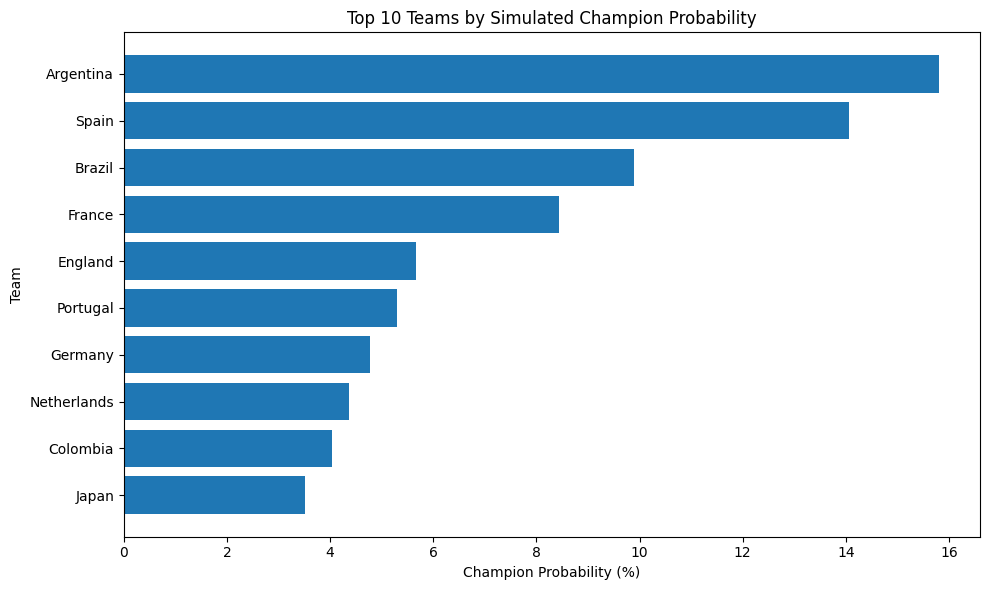

✅ Chart saved:
/content/drive/MyDrive/FIFA_World_Cup_Project/results/top10_champion_probability.png


In [38]:
# ==========================================
# 131 — CHAMPION PROBABILITY CHART
# ==========================================

import matplotlib.pyplot as plt

top10 = (
    final_tournament_probabilities
    .sort_values(
        "Champion %",
        ascending=False
    )
    .head(10)
    .sort_values("Champion %")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10.index,
    top10["Champion %"]
)

plt.xlabel("Champion Probability (%)")
plt.ylabel("Team")
plt.title(
    "Top 10 Teams by Simulated Champion Probability"
)

plt.tight_layout()

chart1_path = (
    RESULTS_PATH
    + "top10_champion_probability.png"
)

plt.savefig(
    chart1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved:")
print(chart1_path)

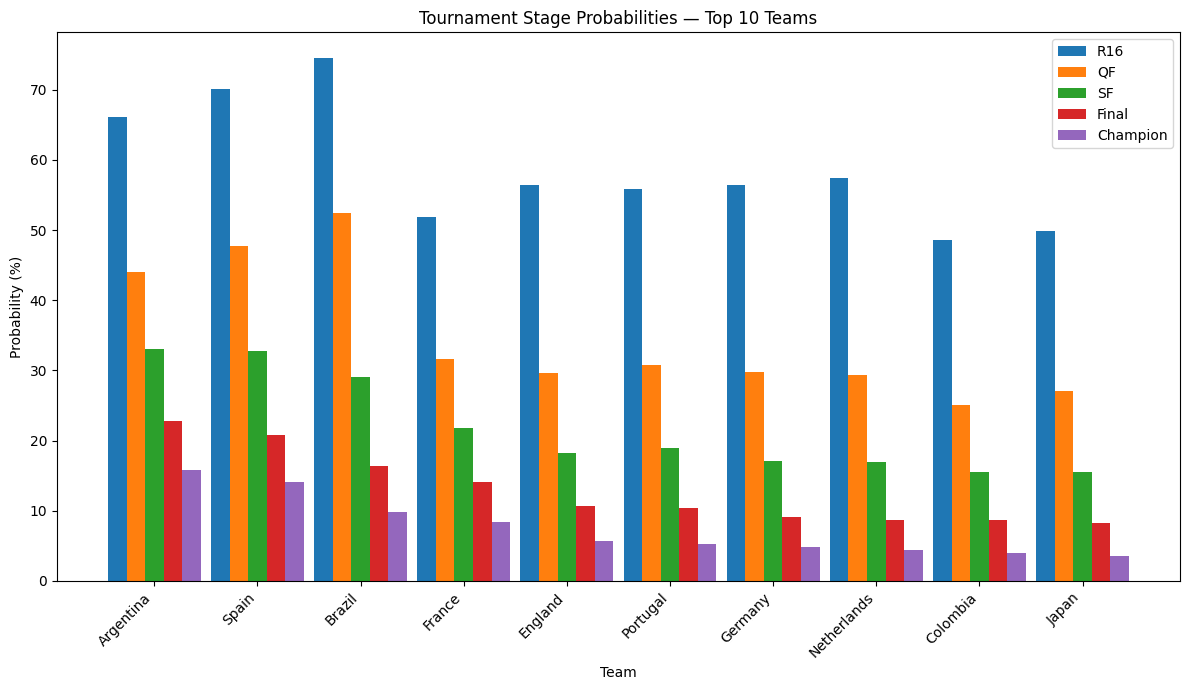

✅ Chart saved:
/content/drive/MyDrive/FIFA_World_Cup_Project/results/tournament_stage_probabilities.png


In [39]:
# ==========================================
# 132 — TOURNAMENT PROGRESSION CHART
# ==========================================

top10_teams = (
    final_tournament_probabilities
    .sort_values(
        "Champion %",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 7))

x = np.arange(len(top10_teams))
width = 0.18

stages = [
    ("R16 %", "R16"),
    ("QF %", "QF"),
    ("SF %", "SF"),
    ("Final %", "Final"),
    ("Champion %", "Champion")
]

for i, (column, label) in enumerate(stages):

    plt.bar(
        x + i * width,
        top10_teams[column],
        width,
        label=label
    )

plt.xticks(
    x + width * 2,
    top10_teams.index,
    rotation=45,
    ha="right"
)

plt.ylabel("Probability (%)")

plt.xlabel("Team")

plt.title(
    "Tournament Stage Probabilities — Top 10 Teams"
)

plt.legend()

plt.tight_layout()

chart2_path = (
    RESULTS_PATH
    + "tournament_stage_probabilities.png"
)

plt.savefig(
    chart2_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Chart saved:")
print(chart2_path)

In [40]:
# ==========================================
# 133 — FINAL PROJECT VALIDATION
# ==========================================

print("=" * 55)
print("       FIFA WORLD CUP PROJECT AUDIT")
print("=" * 55)

# 1. Model
assert final_engineered_calibrated_rf is not None
print("✅ Final calibrated model loaded")

# 2. Tournament teams
total_teams = sum(
    len(teams) for teams in groups.values()
)

assert len(groups) == 12
assert total_teams == 48

print("✅ 12 groups / 48 teams")

# 3. Probability cache
assert len(probability_cache) == 48 * 47

print("✅ 2,256 matchup probabilities cached")

# 4. Monte Carlo simulations
assert final_monte_carlo_stats is not None

print("✅ 10,000 tournaments simulated")

# 5. Stage counts
assert simulation_results["r16"].sum() == 160000
assert simulation_results["qf"].sum() == 80000
assert simulation_results["sf"].sum() == 40000
assert simulation_results["final"].sum() == 20000
assert simulation_results["champion"].sum() == 10000

print("✅ Tournament stage counts validated")

# 6. Champion probabilities
champion_probability_sum = (
    final_tournament_probabilities["Champion %"].sum()
)

assert abs(champion_probability_sum - 100) < 0.01

print(
    f"✅ Champion probability sum: "
    f"{champion_probability_sum:.2f}%"
)

# 7. Output files
required_files = [
    "final_model_metrics.csv",
    "final_test_predictions.csv",
    "final_test_probabilities.csv",
    "monte_carlo_tournament_probabilities.csv",
    "monte_carlo_raw_counts.csv",
    "top10_champion_probability.png",
    "tournament_stage_probabilities.png"
]

print("\nOutput files:")

for filename in required_files:

    exists = os.path.exists(
        RESULTS_PATH + filename
    )

    print(
        "✅" if exists else "❌",
        filename
    )

    assert exists

print()
print("=" * 55)
print("✅ FINAL PROJECT AUDIT PASSED")
print("=" * 55)

       FIFA WORLD CUP PROJECT AUDIT
✅ Final calibrated model loaded
✅ 12 groups / 48 teams
✅ 2,256 matchup probabilities cached
✅ 10,000 tournaments simulated
✅ Tournament stage counts validated
✅ Champion probability sum: 100.00%

Output files:
✅ final_model_metrics.csv
✅ final_test_predictions.csv
✅ final_test_probabilities.csv
✅ monte_carlo_tournament_probabilities.csv
✅ monte_carlo_raw_counts.csv
✅ top10_champion_probability.png
✅ tournament_stage_probabilities.png

✅ FINAL PROJECT AUDIT PASSED
